<a href="https://colab.research.google.com/github/nmansour67/skills-introduction-to-github/blob/main/USJ_MH_LM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
╔══════════════════════════════════════════════════════════════════════════════════════╗
║   USJ MENTAL HEALTH STUDY — COMPREHENSIVE ML ANALYSIS PIPELINE FOR GOOGLE COLAB   ║
║   Cross-sectional Study: Medical Students & Residents, University of Saint Joseph  ║
║   Instruments: PSS-10 | PHQ-9 | DASS-21 | CAGE-AID | Sociodemographic Survey     ║
║   Python Version: 3.10+ | Runtime: GPU not required                                ║
╚══════════════════════════════════════════════════════════════════════════════════════╝

SECTIONS:
    SECTION 1  — Environment Setup & Library Installation
    SECTION 2  — Data Upload & Ingestion
    SECTION 3  — Data Cleaning & Preprocessing
    SECTION 4  — Feature Engineering
    SECTION 5  — Descriptive Statistics & Univariate Analysis
    SECTION 6  — Bivariate & Correlation Analysis
    SECTION 7  — ML Models: Depression Classification (PHQ-9 ≥ 10)
    SECTION 8  — ML Models: Suicidal Ideation Classification (PHQ-9 Q9 > 0)
    SECTION 9  — ML Models: High Stress Classification (PSS High Category)
    SECTION 10 — Explainable AI (SHAP) — Feature Importance
    SECTION 11 — Clustering (K-Means + PCA)
    SECTION 12 — Risk Profile Generation & Clinical Insights
    SECTION 13 — Full Visualization Dashboard
"""



'\n╔══════════════════════════════════════════════════════════════════════════════════════╗\n║   USJ MENTAL HEALTH STUDY — COMPREHENSIVE ML ANALYSIS PIPELINE FOR GOOGLE COLAB   ║\n║   Cross-sectional Study: Medical Students & Residents, University of Saint Joseph  ║\n║   Instruments: PSS-10 | PHQ-9 | DASS-21 | CAGE-AID | Sociodemographic Survey     ║\n║   Python Version: 3.10+ | Runtime: GPU not required                                ║\n╚══════════════════════════════════════════════════════════════════════════════════════╝\n\nSECTIONS:\n    SECTION 1  — Environment Setup & Library Installation\n    SECTION 2  — Data Upload & Ingestion\n    SECTION 3  — Data Cleaning & Preprocessing\n    SECTION 4  — Feature Engineering\n    SECTION 5  — Descriptive Statistics & Univariate Analysis\n    SECTION 6  — Bivariate & Correlation Analysis\n    SECTION 7  — ML Models: Depression Classification (PHQ-9 ≥ 10)\n    SECTION 8  — ML Models: Suicidal Ideation Classification (PHQ-9 Q9 > 0)\n    SECTI

In [2]:
# ==============================================================================
# SECTION 1 — ENVIRONMENT SETUP & LIBRARY INSTALLATION
# ==============================================================================
print("=" * 70)
print("SECTION 1: Installing and importing required libraries...")
print("=" * 70)

import subprocess, sys

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Install any potentially missing packages
for pkg in ["shap", "imbalanced-learn", "openpyxl", "xlrd", "xgboost",
            "lightgbm", "scikit-learn", "matplotlib", "seaborn", "plotly",
            "scipy", "statsmodels", "pandas", "numpy"]:
    install(pkg)

# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    f1_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance

# XGBoost & LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Class imbalance
from imblearn.over_sampling import SMOTE

# Stats
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal, pointbiserialr
import statsmodels.api as sm
import statsmodels.formula.api as smf

# SHAP
import shap

# Matplotlib style
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
PALETTE = sns.color_palette("Set2")
sns.set_palette(PALETTE)

print("✅ All libraries installed and imported successfully.\n")




SECTION 1: Installing and importing required libraries...
✅ All libraries installed and imported successfully.



In [4]:
# ==============================================================================
# SECTION 2 — DATA UPLOAD & INGESTION
# ==============================================================================
print("=" * 70)
print("SECTION 2: Data Upload & Ingestion")
print("=" * 70)

from google.colab import files

print("\n📂 Please upload the Excel file: ETUDE_SANTE_MENTALE_ETUDIANTS-10012026.xlsx")
print("   (When the upload button appears, select your file and wait for confirmation)\n")

uploaded = files.upload()

# Load the file
filename = list(uploaded.keys())[0]
print(f"\n✅ File received: {filename}")

# Read the primary data sheet (2024-2025 cohort)
df_raw = pd.read_excel(filename, sheet_name="Année académique 2024-2025")
print(f"   Rows loaded from 'Année académique 2024-2025': {df_raw.shape[0]}")
print(f"   Columns: {df_raw.shape[1]}\n")

# Optionally also read the 'TOUT' sheet (all years combined) for reference
try:
    df_all = pd.read_excel(filename, sheet_name="TOUT ")
    print(f"   Rows loaded from 'TOUT' sheet: {df_all.shape[0]}")
except Exception:
    df_all = None
    print("   'TOUT' sheet not loaded (optional).")

print("\nColumn preview:")
print(df_raw.columns.tolist()[:20], "...\n")




SECTION 2: Data Upload & Ingestion

📂 Please upload the Excel file: ETUDE_SANTE_MENTALE_ETUDIANTS-10012026.xlsx
   (When the upload button appears, select your file and wait for confirmation)



Saving USJ_MH_LM_Finalone.xlsx to USJ_MH_LM_Finalone.xlsx

✅ File received: USJ_MH_LM_Finalone.xlsx
   Rows loaded from 'Année académique 2024-2025': 335
   Columns: 260

   'TOUT' sheet not loaded (optional).

Column preview:
['ID de la réponse', 'Date de soumission', 'Dernière page', 'Langue de départ', 'Tête de série', 'Date de lancement', 'Date de la dernière action', 'Adresse IP', '1. Vous êtes :', 'Sexe', 'Age', '3. Statut financier (de la famille) :', 'Statut Financier', '4. Libanais', 'Libanais ', '4. Libanais   [Autre]', '5. Statut marital :', 'Statut marital', '5. Statut marital :  [Autre]', "6. Nombre d'enfants à charge :\xa0"] ...



In [5]:
# ==============================================================================
# SECTION 3 — DATA CLEANING & PREPROCESSING
# ==============================================================================
print("=" * 70)
print("SECTION 3: Data Cleaning & Preprocessing")
print("=" * 70)

# ── 3.1  Select and rename the pre-coded columns already present in the sheet ──
# The Excel sheet contains BOTH raw response text AND pre-coded numeric columns.
# We use only the coded numeric columns (already computed by the research team).

RENAME_MAP = {
    "Sexe":                           "sex",          # 0=Female, 1=Male
    "Age":                            "age",
    "Statut Financier":               "fin_status",   # 0=<500, 1=500-1000, 2=1000-2000, 3=>2000
    "Libanais ":                      "lebanese",     # 1=Yes, 0=No
    "Statut marital":                 "marital",      # 0=Single, 1=Couple, 2=Married, 3=Divorced
    "Region ":                        "region",       # 1=Bey, 2=ML, 3=N.Leb, 4=S.Leb, 5=Nabatieh, 6=Bekaa
    "Année academique":               "acad_year",    # 1-7=Students, 8-12=Residents
    "ATCD psy avt entrée":            "psych_hx_personal",  # 0=No, 1=Yes
    "Trouble Psy en Famille":         "psych_hx_family",    # 0=No, 1=Yes
    "Trouble psy actuel ":            "psych_current",      # 0=No, 1=Yes
    "Tx psy actu":                    "tx_current",         # 0=No, 1=Yes

    # Stress factors (Q17), coded 0-3 (Not at all → A lot)
    "Charge académique/examen":                           "sf_academic",
    "Habitudes d'étude inadéquates":                     "sf_study_habits",
    "Mauvaises compétences en gestion du temps":         "sf_time_mgmt",
    "Problèmes familiaux ou personnels":                  "sf_family",
    "Situation économique":                               "sf_economic",
    "Instabilité politique":                              "sf_political",
    "Relations sociales/amoureuses":                      "sf_social",
    "Santé physique ":                                   "sf_physical",
    "Trouble psychiatrique/psychologique":                "sf_psych",
    "Stress lié à la guerre":                            "sf_war",
    "Déplacement à cause de la guerre":                  "sf_displacement",

    # Coping strategies (Q18), coded 0-3 (Never → Frequently)
    "Activité sportive":                                         "cp_sport",
    "Yoga/Pilates":                                              "cp_yoga",
    "Mindfulness/Méditation":                                   "cp_mindfulness",
    "Sortie avec des amis/proches":                             "cp_friends",
    "Lecture d'un livre":                                       "cp_reading",
    "Regarder la télévision/des films":                         "cp_tv",
    "Sommeil/Repos":                                             "cp_sleep",
    "Sauter des cours":                                          "cp_skip_class",
    "Jouer/écouter de la musique":                              "cp_music",
    "Participer à des activités extra-académiques/Pratique d'un hobby": "cp_hobby",
    "Faire du shopping":                                         "cp_shopping",
    "Manger":                                                    "cp_eating",
    "Parler à un ami ou un membre de la famille":               "cp_talk_family",
    "Participer à des activités religieuses ou spirituelles":   "cp_religion",
    "Consulter un professionnel de santé mentale":              "cp_professional",
    "Activités sociales sans alcool":                           "cp_social_sober",
    "Activités sociales avec consommation d'alcool":            "cp_social_alcohol",
    "Activités sociales avec consommation d'alcool.1":         "cp_drink_alone",
    "Utiliser des substances (Cannabis, stimulants, ou autres...)": "cp_substances",

    # Alcohol / substances
    "Consommation alcool":                               "alcohol_use",       # 0=No, 1=Yes
    "Consommation substances illicites ":               "substance_use",     # 0=No, 1=Yes
    "Consommation alcool ou substances illicites ":     "alc_or_subs",       # 0=No, 1=Yes

    # Validated scales — raw items
    "Perceived stress scale Q1 ": "pss_q1",
    "PSS Q2 ": "pss_q2",
    "PSS Q3 ": "pss_q3",
    "PSS Q4 ": "pss_q4",
    "PSS Q5":  "pss_q5",
    "PSS Q6":  "pss_q6",
    "PSS Q7":  "pss_q7",
    "PSS Q8":  "pss_q8",
    "PSS Q9":  "pss_q9",
    "PSS Q10": "pss_q10",

    # PSS computed
    "PSS SCORE":    "pss_score",
    "PSS Category": "pss_cat",   # 0=Low(0-13), 1=Mod(14-26), 2=High(27-40)

    # PHQ-9 items
    "PHQ 9 Q1 ": "phq_q1",
    "PHQ 9 Q 2": "phq_q2",
    "PHQ 9 Q3":  "phq_q3",
    "PHQ 9 Q4":  "phq_q4",
    "PHQ9 Q5":   "phq_q5",
    "PHQ9 Q6":   "phq_q6",
    "PHQ9 Q7":   "phq_q7",
    "PHQ9 Q8":   "phq_q8",
    "PHQ9 Q9":   "phq_q9",      # Suicidal ideation item

    # PHQ-9 computed
    "PHQ9 Score ":  "phq_score",
    "PHQ9 Category": "phq_cat",  # 0=None, 1=Mild, 2=Mod, 3=Mod-Severe, 4=Severe
    "Impact ":       "phq_impact",

    # DASS-21 items (Q1-Q21 mapped)
    "DASS 21 Q1": "dass_q1",  "DASS 21 Q2": "dass_q2",  "DASS 21 Q3": "dass_q3",
    "DASS 21 Q4": "dass_q4",  "DASS 21 Q5": "dass_q5",  "DASS 21 Q6": "dass_q6",
    "DASS 21 Q7": "dass_q7",  "DASS 21 Q8": "dass_q8",  "DASS 21 Q9": "dass_q9",
    "DASS 21 Q10": "dass_q10","DASS 21 Q11": "dass_q11","DASS 21 Q12": "dass_q12",
    "DASS 21 Q13": "dass_q13","DASS 21 Q14": "dass_q14","DASS 21 Q15": "dass_q15",
    "DASS 21 Q16": "dass_q16","DASS 21 Q17": "dass_q17","DASS 21 Q18": "dass_q18",
    "DASS 21 Q19": "dass_q19","DASS 21 Q20": "dass_q20","DASS 21 Q21": "dass_q21",

    # DASS computed
    "DASS D score": "dass_dep_score",
    "DASS D Categ": "dass_dep_cat",   # 0=Normal, 1=Mild, 2=Mod, 3=Severe, 4=ExtSevere
    "DASS A Score": "dass_anx_score",
    "DASS A Categ": "dass_anx_cat",
    "DASS S Score": "dass_str_score",
    "DASS S Categ": "dass_str_cat",

    # CAGE-AID
    "CAGE AID Q1": "cage_q1",
    "CAGE AID Q2": "cage_q2",
    "CAGE AID Q3": "cage_q3",
    "CAGE AID Q4": "cage_q4",
    "CAGE AID score ":  "cage_score",
    "CAGE AID Categ":   "cage_cat",   # 0=<2 (neg), 1=≥2 (pos)

    # Satisfaction
    "Satisfaction de la formation": "training_satisfaction",  # 0-4
}

# Perform rename (only map columns that exist in the sheet)
cols_available = {k: v for k, v in RENAME_MAP.items() if k in df_raw.columns}
df = df_raw.rename(columns=cols_available)

# Keep only coded/numeric columns (drop raw text and metadata)
keep_cols = list(cols_available.values())
df = df[keep_cols].copy()

print(f"✅ Selected {len(keep_cols)} coded/numeric columns.\n")

# ── 3.2  Data types & basic cleaning ──
# Convert everything to numeric, coerce errors to NaN
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with no PSS or PHQ-9 score (critical outcomes)
before = len(df)
df = df.dropna(subset=["pss_score", "phq_score"])
print(f"   Rows after dropping missing PSS/PHQ-9 scores: {len(df)}  (removed {before - len(df)})")

# ── 3.3  Derived academic level grouping ──
# acad_year: 1-3=Pre-clinical, 4-7=Clinical, 8-12=Residents
def level_group(y):
    if pd.isna(y): return np.nan
    y = int(y)
    if y <= 3: return 0     # Pre-clinical
    elif y <= 7: return 1   # Clinical
    else: return 2          # Resident
df["level"] = df["acad_year"].apply(level_group)

# ── 3.4  Beirut/Mount Lebanon binary region ──
df["region_blm"] = df["region"].apply(lambda x: 1 if x in [1, 2] else (0 if not pd.isna(x) else np.nan))

print(f"\n✅ Data cleaning complete. Final dataset: {df.shape[0]} rows × {df.shape[1]} columns.")
print(f"\nMissing value summary (top 15 columns with NaN):")
mv = df.isnull().sum().sort_values(ascending=False).head(15)
print(mv[mv > 0].to_string())




SECTION 3: Data Cleaning & Preprocessing
✅ Selected 102 coded/numeric columns.

   Rows after dropping missing PSS/PHQ-9 scores: 335  (removed 0)

✅ Data cleaning complete. Final dataset: 335 rows × 104 columns.

Missing value summary (top 15 columns with NaN):
phq_impact    316
cage_q4       243
cage_cat      243
cage_q3       243
cage_q2       243
cage_q1       243
cage_score    243


In [6]:
# ==============================================================================
# SECTION 4 — FEATURE ENGINEERING
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 4: Feature Engineering")
print("=" * 70)

# ── 4.1  Binary outcome variables (primary ML targets) ──
df["dep_moderate_plus"] = (df["phq_score"] >= 10).astype(int)          # PHQ-9 ≥ 10
df["suicidal_ideation"]  = (df["phq_q9"] > 0).astype(int)              # PHQ-9 Q9 > 0
df["high_stress_pss"]    = (df["pss_cat"] == 2).astype(int)            # PSS High (27-40)
df["dass_dep_mplus"]     = (df["dass_dep_cat"] >= 2).astype(int)       # DASS-D ≥ Moderate
df["dass_anx_mplus"]     = (df["dass_anx_cat"] >= 2).astype(int)       # DASS-A ≥ Moderate
df["dass_str_mplus"]     = (df["dass_str_cat"] >= 2).astype(int)       # DASS-S ≥ Moderate
df["cage_positive"]      = (df["cage_cat"] == 1).astype(int)           # CAGE-AID ≥ 2

# ── 4.2  Composite stress factor score ──
sf_cols = ["sf_academic","sf_study_habits","sf_time_mgmt","sf_family",
           "sf_economic","sf_political","sf_social","sf_physical","sf_psych",
           "sf_war","sf_displacement"]
df["stress_factor_total"] = df[sf_cols].sum(axis=1, skipna=True)

# ── 4.3  Coping style indices (adaptive vs maladaptive) ──
adaptive_coping = ["cp_sport","cp_yoga","cp_mindfulness","cp_friends",
                   "cp_reading","cp_music","cp_hobby","cp_talk_family",
                   "cp_religion","cp_social_sober","cp_professional"]
maladaptive_coping = ["cp_tv","cp_skip_class","cp_shopping","cp_eating",
                      "cp_social_alcohol","cp_drink_alone","cp_substances"]

df["coping_adaptive"]      = df[adaptive_coping].mean(axis=1, skipna=True)
df["coping_maladaptive"]   = df[maladaptive_coping].mean(axis=1, skipna=True)
df["coping_ratio"]         = df["coping_adaptive"] / (df["coping_maladaptive"] + 0.01)

# ── 4.4  Psychiatric vulnerability index ──
df["psych_vulnerability"] = (
    df["psych_hx_personal"].fillna(0) +
    df["psych_hx_family"].fillna(0) +
    df["psych_current"].fillna(0)
)

# ── 4.5  PSS subscales (Perceived Helplessness vs Perceived Self-Efficacy) ──
# Helplessness items: Q1, Q2, Q3, Q6, Q9, Q10 (positively worded for stress)
# Self-efficacy items: Q4, Q5, Q7, Q8 (reverse-coded)
pss_helplessness_items = ["pss_q1","pss_q2","pss_q3","pss_q6","pss_q9","pss_q10"]
pss_efficacy_items     = ["pss_q4","pss_q5","pss_q7","pss_q8"]
df["pss_helplessness"]  = df[pss_helplessness_items].sum(axis=1, skipna=True)
df["pss_self_efficacy"] = df[pss_efficacy_items].sum(axis=1, skipna=True)

# ── 4.6  DASS total distress score ──
df["dass_total"] = df[["dass_dep_score","dass_anx_score","dass_str_score"]].sum(axis=1, skipna=True)

# ── 4.7  Socioeconomic risk flag ──
df["low_income"] = (df["fin_status"] <= 1).astype(int)  # < 1000 USD/month

# ── 4.8  War-related stress ──
df["war_stress_composite"] = (
    df["sf_war"].fillna(0) + df["sf_displacement"].fillna(0) + df["sf_political"].fillna(0)
)

print("✅ Feature engineering complete. New features created:")
new_feats = [
    "dep_moderate_plus", "suicidal_ideation", "high_stress_pss",
    "dass_dep_mplus", "dass_anx_mplus", "dass_str_mplus", "cage_positive",
    "stress_factor_total", "coping_adaptive", "coping_maladaptive", "coping_ratio",
    "psych_vulnerability", "pss_helplessness", "pss_self_efficacy",
    "dass_total", "low_income", "war_stress_composite", "level", "region_blm"
]
for f in new_feats:
    print(f"   + {f}")





SECTION 4: Feature Engineering
✅ Feature engineering complete. New features created:
   + dep_moderate_plus
   + suicidal_ideation
   + high_stress_pss
   + dass_dep_mplus
   + dass_anx_mplus
   + dass_str_mplus
   + cage_positive
   + stress_factor_total
   + coping_adaptive
   + coping_maladaptive
   + coping_ratio
   + psych_vulnerability
   + pss_helplessness
   + pss_self_efficacy
   + dass_total
   + low_income
   + war_stress_composite
   + level
   + region_blm


In [7]:
# ==============================================================================
# SECTION 5 — DESCRIPTIVE STATISTICS & UNIVARIATE ANALYSIS
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 5: Descriptive Statistics & Univariate Analysis")
print("=" * 70)

n = len(df)
print(f"\n{'─'*60}")
print(f"  SAMPLE DESCRIPTION  (N = {n})")
print(f"{'─'*60}")

# Continuous variables
cont_vars = {
    "Age":                     "age",
    "PSS Score (0-40)":        "pss_score",
    "PHQ-9 Score (0-27)":      "phq_score",
    "DASS-D Score":            "dass_dep_score",
    "DASS-A Score":            "dass_anx_score",
    "DASS-S Score":            "dass_str_score",
    "Stress Factor Total":     "stress_factor_total",
    "Adaptive Coping Index":   "coping_adaptive",
    "Maladaptive Coping Idx":  "coping_maladaptive",
}
print("\nContinuous Variables:")
print(f"{'Variable':<30}{'Mean':>10}{'SD':>10}{'Median':>10}{'Min':>8}{'Max':>8}")
print("─" * 76)
for label, col in cont_vars.items():
    if col in df.columns:
        v = df[col].dropna()
        print(f"{label:<30}{v.mean():>10.2f}{v.std():>10.2f}{v.median():>10.2f}{v.min():>8.1f}{v.max():>8.1f}")

# Categorical / binary variables
cat_vars = {
    "Sex (Male)":                  "sex",
    "Lebanese":                    "lebanese",
    "Low income (<1000 USD)":      "low_income",
    "Level: Pre-clinical":         None,
    "Level: Clinical":             None,
    "Level: Resident":             None,
    "Personal psych history":      "psych_hx_personal",
    "Family psych history":        "psych_hx_family",
    "PHQ-9 ≥ 10 (Dep. Mod+)":    "dep_moderate_plus",
    "Suicidal ideation (Q9>0)":    "suicidal_ideation",
    "PSS High Stress":             "high_stress_pss",
    "DASS-D Moderate+":           "dass_dep_mplus",
    "DASS-A Moderate+":           "dass_anx_mplus",
    "DASS-S Moderate+":           "dass_str_mplus",
    "Alcohol use":                 "alcohol_use",
    "CAGE-AID Positive (≥2)":     "cage_positive",
}
print("\n\nCategorical / Binary Variables:")
print(f"{'Variable':<35}{'n':>6}{'%':>8}")
print("─" * 51)
for label, col in cat_vars.items():
    if col is None:  # level sub-groups
        if "Pre-clinical" in label:
            val = df["level"].eq(0).sum()
        elif "Clinical" in label:
            val = df["level"].eq(1).sum()
        else:
            val = df["level"].eq(2).sum()
        print(f"  {label:<33}{val:>6}{val/n*100:>7.1f}%")
    elif col in df.columns:
        val = df[col].eq(1).sum()
        print(f"  {label:<33}{val:>6}{val/n*100:>7.1f}%")

print(f"\n✅ Descriptive statistics complete.")





SECTION 5: Descriptive Statistics & Univariate Analysis

────────────────────────────────────────────────────────────
  SAMPLE DESCRIPTION  (N = 335)
────────────────────────────────────────────────────────────

Continuous Variables:
Variable                            Mean        SD    Median     Min     Max
────────────────────────────────────────────────────────────────────────────
Age                                22.50      2.47     22.00    18.0    31.0
PSS Score (0-40)                   19.45      6.85     20.00     0.0    38.0
PHQ-9 Score (0-27)                  6.71      5.74      5.00     0.0    27.0
DASS-D Score                        9.84     10.04      8.00     0.0    42.0
DASS-A Score                        7.59      7.92      6.00     0.0    40.0
DASS-S Score                       11.50      9.14     10.00     0.0    36.0
Stress Factor Total                13.81      6.22     13.00     0.0    33.0
Adaptive Coping Index               1.47      0.47      1.45     0.0    


SECTION 6: Bivariate & Correlation Analysis


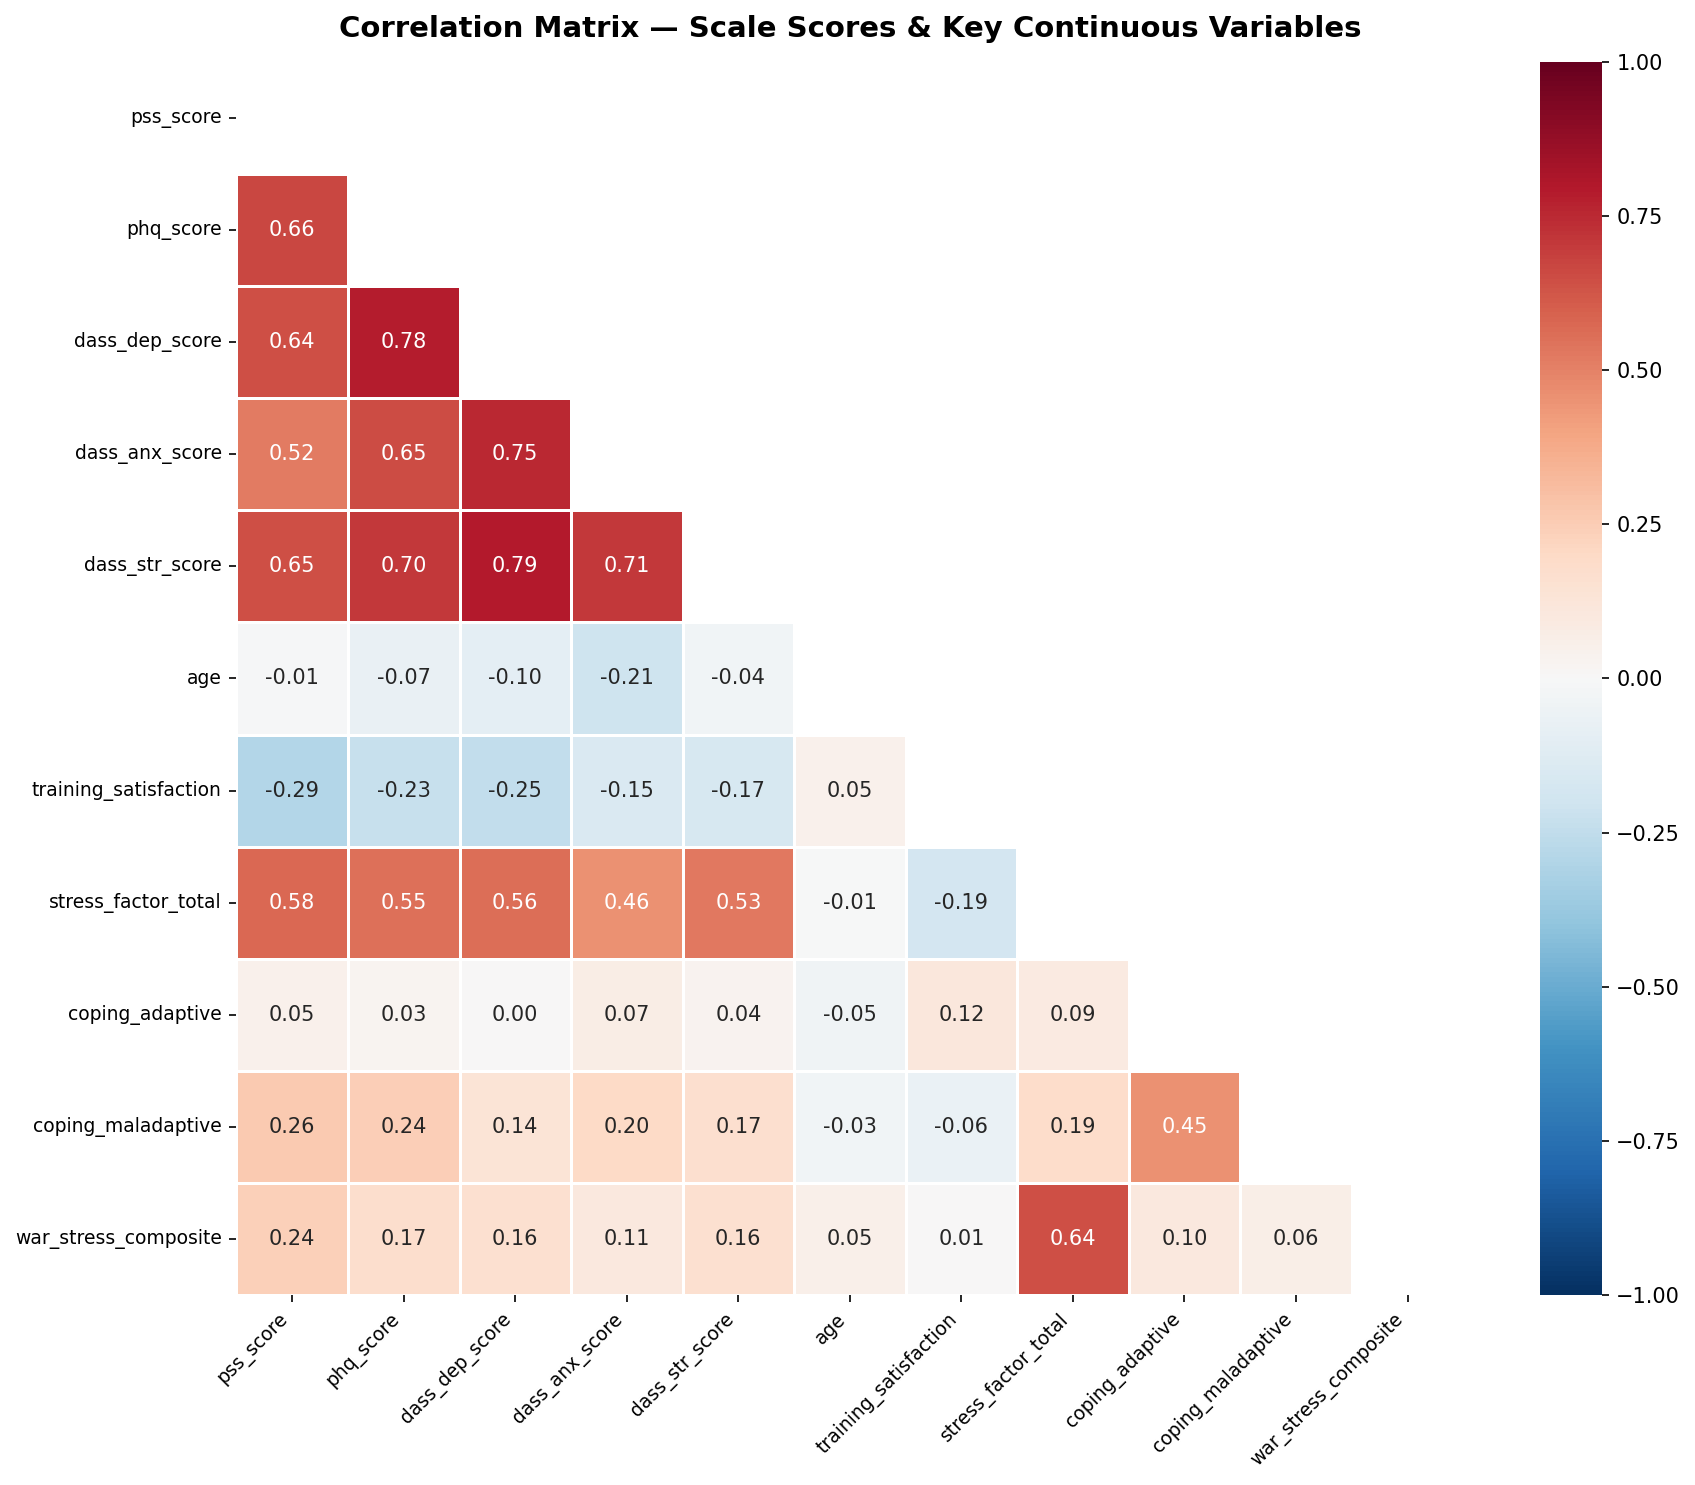

   ✅ Figure saved: fig_01_correlation_matrix.png

── PHQ-9 Score by risk factors (Mann-Whitney U) ──
  Sex (M vs F): G0=7.03±5.67  |  G1=6.42±5.80  |  p=0.1865
  Personal psych Hx: G0=6.52±5.55  |  G1=10.56±7.92  |  p=0.0556
  Family psych Hx: G0=5.95±5.26  |  G1=9.33±6.54  |  p=0.0001
  Low income: G0=6.41±5.45  |  G1=7.77±6.60  |  p=0.2360
  CAGE-AID positive: G0=6.58±5.66  |  G1=9.53±6.82  |  p=0.0573

── PSS Score by risk factors (Mann-Whitney U) ──
  Sex (M vs F): G0=20.89±6.77  |  G1=18.16±6.68  |  p=0.0001
  Personal psych Hx: G0=19.23±6.68  |  G1=23.81±8.83  |  p=0.0074
  Family psych Hx: G0=18.55±6.54  |  G1=22.55±7.02  |  p=0.0000
  Low income: G0=19.43±6.60  |  G1=19.53±7.73  |  p=0.9127

── PHQ-9 Score by Academic Level (Kruskal-Wallis) ──
  Pre-clinical: 7.72 ± 5.91  (n=81)
  Clinical: 6.62 ± 5.87  (n=195)
  Resident: 5.63 ± 4.83  (n=59)
  Kruskal-Wallis H=4.96, p=0.0838

✅ Bivariate analysis complete.


In [8]:
# ==============================================================================
# SECTION 6 — BIVARIATE & CORRELATION ANALYSIS
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 6: Bivariate & Correlation Analysis")
print("=" * 70)

# ── 6.1  Pearson correlation matrix (continuous outcomes) ──
corr_cols = ["pss_score","phq_score","dass_dep_score","dass_anx_score",
             "dass_str_score","age","training_satisfaction","stress_factor_total",
             "coping_adaptive","coping_maladaptive","war_stress_composite"]
corr_cols = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            xticklabels=corr_cols, yticklabels=corr_cols)
ax.set_title("Correlation Matrix — Scale Scores & Key Continuous Variables",
             fontsize=14, pad=12, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig("fig_01_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_01_correlation_matrix.png")

# ── 6.2  Key bivariate comparisons for primary outcomes ──
def compare_groups(df, groupvar, outcome_cont, outcome_label):
    """Mann-Whitney U test between two groups on continuous outcome."""
    g0 = df.loc[df[groupvar] == 0, outcome_cont].dropna()
    g1 = df.loc[df[groupvar] == 1, outcome_cont].dropna()
    stat, p = mannwhitneyu(g0, g1, alternative="two-sided")
    print(f"  {outcome_label}: G0={g0.mean():.2f}±{g0.std():.2f}  |  "
          f"G1={g1.mean():.2f}±{g1.std():.2f}  |  p={p:.4f}")
    return p

print("\n── PHQ-9 Score by risk factors (Mann-Whitney U) ──")
for var, lbl in [("sex","Sex (M vs F)"), ("psych_hx_personal","Personal psych Hx"),
                 ("psych_hx_family","Family psych Hx"), ("low_income","Low income"),
                 ("cage_positive","CAGE-AID positive")]:
    if var in df.columns:
        compare_groups(df, var, "phq_score", lbl)

print("\n── PSS Score by risk factors (Mann-Whitney U) ──")
for var, lbl in [("sex","Sex (M vs F)"), ("psych_hx_personal","Personal psych Hx"),
                 ("psych_hx_family","Family psych Hx"), ("low_income","Low income")]:
    if var in df.columns:
        compare_groups(df, var, "pss_score", lbl)

print("\n── PHQ-9 Score by Academic Level (Kruskal-Wallis) ──")
groups_level = [df.loc[df["level"] == i, "phq_score"].dropna() for i in range(3)]
h, p = kruskal(*groups_level)
labels = ["Pre-clinical","Clinical","Resident"]
for i, g in enumerate(groups_level):
    print(f"  {labels[i]}: {g.mean():.2f} ± {g.std():.2f}  (n={len(g)})")
print(f"  Kruskal-Wallis H={h:.2f}, p={p:.4f}")

print(f"\n✅ Bivariate analysis complete.")





SECTION 7: ML Models — Depression (PHQ-9 ≥ 10)
   After SMOTE: Class 0=187, Class 1=187

Model                       AUC-ROC    F1 (pos)  Accuracy
────────────────────────────────────────────────────────────
  Logistic Regression         0.888       0.667     0.786
  Random Forest               0.928       0.739     0.857
  XGBoost                     0.902       0.739     0.857
  LightGBM                    0.900       0.636     0.810
  Gradient Boosting           0.913       0.744     0.869

  ★ Best model for Depression: Random Forest (AUC=0.928)


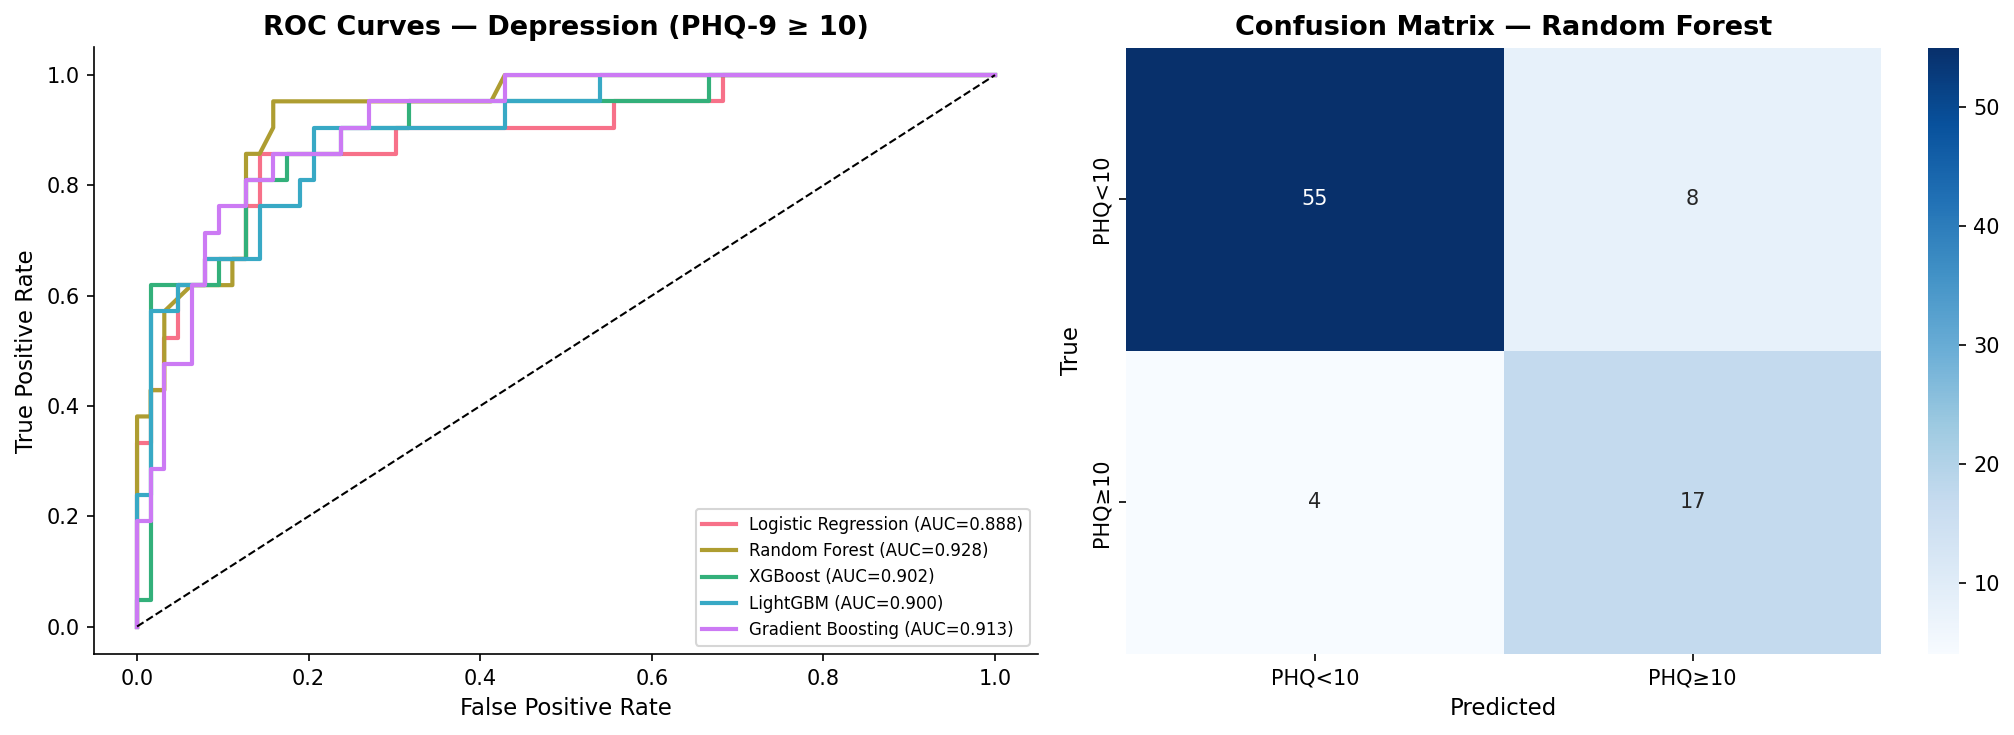

   ✅ Figure saved: fig_02_depression_roc_cm.png

  5-Fold CV AUC: 0.917 ± 0.020
  Full Classification Report:

              precision    recall  f1-score   support

  PHQ-9 < 10       0.93      0.87      0.90        63
  PHQ-9 ≥ 10       0.68      0.81      0.74        21

    accuracy                           0.86        84
   macro avg       0.81      0.84      0.82        84
weighted avg       0.87      0.86      0.86        84



In [9]:
# ==============================================================================
# SECTION 7 — ML MODELS: DEPRESSION CLASSIFICATION (PHQ-9 ≥ 10)
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 7: ML Models — Depression (PHQ-9 ≥ 10)")
print("=" * 70)

# ── 7.1  Feature set ──
PREDICTOR_COLS = [
    # Sociodemographic
    "sex","age","fin_status","lebanese","marital","region_blm","level","low_income",
    # Psychiatric history
    "psych_hx_personal","psych_hx_family","psych_current",
    # Stress (PSS)
    "pss_score","pss_helplessness","pss_self_efficacy",
    # DASS subscales
    "dass_anx_score","dass_str_score",
    # Stress factors
    "sf_academic","sf_study_habits","sf_time_mgmt","sf_family","sf_economic",
    "sf_political","sf_social","sf_physical","sf_psych","sf_war","sf_displacement",
    "stress_factor_total","war_stress_composite",
    # Coping
    "coping_adaptive","coping_maladaptive","coping_ratio",
    "cp_professional","cp_skip_class","cp_substances",
    # Alcohol/substances
    "alcohol_use","substance_use",
    # Satisfaction
    "training_satisfaction",
    # Engineered
    "psych_vulnerability","dass_total",
]

TARGET_DEP = "dep_moderate_plus"

# Only keep columns available in df
feature_cols = [c for c in PREDICTOR_COLS if c in df.columns and c != TARGET_DEP]
df_model = df[feature_cols + [TARGET_DEP]].dropna(subset=[TARGET_DEP])

X = df_model[feature_cols].copy()
y = df_model[TARGET_DEP].copy()

# Impute remaining NaN in features with median
imputer = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=feature_cols)

# ── 7.2  Train/test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.25, random_state=42, stratify=y)

# ── 7.3  Handle class imbalance with SMOTE ──
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"   After SMOTE: Class 0={sum(y_train_sm==0)}, Class 1={sum(y_train_sm==1)}")

# ── 7.4  Train multiple classifiers ──
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
    "XGBoost":             XGBClassifier(n_estimators=300, random_state=42, use_label_encoder=False,
                                          eval_metric="logloss", verbosity=0),
    "LightGBM":            LGBMClassifier(n_estimators=300, random_state=42, class_weight="balanced",
                                           verbose=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results_dep = {}
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

print(f"\n{'Model':<25}{'AUC-ROC':>10}{'F1 (pos)':>12}{'Accuracy':>10}")
print("─" * 60)
for name, model in MODELS.items():
    model.fit(X_train_sc, y_train_sm)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    auc  = roc_auc_score(y_test, y_proba)
    f1   = f1_score(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)
    results_dep[name] = {"model": model, "auc": auc, "f1": f1, "acc": acc,
                          "y_pred": y_pred, "y_proba": y_proba}
    print(f"  {name:<23}{auc:>10.3f}{f1:>12.3f}{acc:>10.3f}")

# Best model by AUC
best_name_dep = max(results_dep, key=lambda k: results_dep[k]["auc"])
best_dep = results_dep[best_name_dep]
print(f"\n  ★ Best model for Depression: {best_name_dep} (AUC={best_dep['auc']:.3f})")

# ── 7.5  ROC curves (all models) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("husl", len(MODELS))
for (name, res), color in zip(results_dep.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)
axes[0].plot([0,1],[0,1],"k--", lw=1)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves — Depression (PHQ-9 ≥ 10)", fontweight="bold")
axes[0].legend(fontsize=8)

# Confusion matrix of best model
cm = confusion_matrix(y_test, best_dep["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["PHQ<10","PHQ≥10"], yticklabels=["PHQ<10","PHQ≥10"])
axes[1].set_title(f"Confusion Matrix — {best_name_dep}", fontweight="bold")
axes[1].set_ylabel("True"); axes[1].set_xlabel("Predicted")
plt.tight_layout()
plt.savefig("fig_02_depression_roc_cm.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_02_depression_roc_cm.png")

# ── 7.6  Cross-validation of best model ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(MODELS[best_name_dep], X_imp, y, cv=cv, scoring="roc_auc")
print(f"\n  5-Fold CV AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"  Full Classification Report:\n")
print(classification_report(y_test, best_dep["y_pred"],
                             target_names=["PHQ-9 < 10","PHQ-9 ≥ 10"]))

# Store best model & preprocessing for SHAP
best_model_dep    = best_dep["model"]
X_test_dep        = X_test_sc
feature_names_dep = feature_cols




In [10]:
# ==============================================================================
# SECTION 8 — ML MODELS: SUICIDAL IDEATION (PHQ-9 Q9 > 0)
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 8: ML Models — Suicidal Ideation (PHQ-9 Q9 > 0)")
print("=" * 70)

TARGET_SI = "suicidal_ideation"

# Exclude PHQ-9 Q9 from features (it IS the target)
feature_cols_si = [c for c in feature_cols if c not in ["suicidal_ideation","phq_q9"]]

df_model_si = df[feature_cols_si + [TARGET_SI]].dropna(subset=[TARGET_SI])
X_si = df_model_si[feature_cols_si].copy()
y_si = df_model_si[TARGET_SI].copy()

X_si_imp = pd.DataFrame(imputer.transform(X_si.reindex(columns=feature_cols,fill_value=np.nan)),
                         columns=feature_cols)
X_si_imp = X_si_imp[feature_cols_si]

X_train_si, X_test_si, y_train_si, y_test_si = train_test_split(
    X_si_imp, y_si, test_size=0.25, random_state=42, stratify=y_si)

sm_si = SMOTE(random_state=42, k_neighbors=min(4, y_train_si.sum()-1))
X_tr_si_sm, y_tr_si_sm = sm_si.fit_resample(X_train_si, y_train_si)

sc_si = StandardScaler()
X_tr_si_sc = sc_si.fit_transform(X_tr_si_sm)
X_te_si_sc = sc_si.transform(X_test_si)

results_si = {}
print(f"\n{'Model':<25}{'AUC-ROC':>10}{'F1 (pos)':>12}{'Accuracy':>10}")
print("─" * 60)
for name, _ in MODELS.items():
    import copy
    m = copy.deepcopy(MODELS[name])
    m.fit(X_tr_si_sc, y_tr_si_sm)
    yp  = m.predict(X_te_si_sc)
    ypr = m.predict_proba(X_te_si_sc)[:, 1]
    auc = roc_auc_score(y_test_si, ypr)
    f1  = f1_score(y_test_si, yp, zero_division=0)
    acc = accuracy_score(y_test_si, yp)
    results_si[name] = {"model": m, "auc": auc, "f1": f1, "y_pred": yp, "y_proba": ypr}
    print(f"  {name:<23}{auc:>10.3f}{f1:>12.3f}{acc:>10.3f}")

best_name_si = max(results_si, key=lambda k: results_si[k]["auc"])
best_si = results_si[best_name_si]
print(f"\n  ★ Best model for Suicidal Ideation: {best_name_si} (AUC={best_si['auc']:.3f})")
print(f"\n  Classification Report:\n")
print(classification_report(y_test_si, best_si["y_pred"],
                             target_names=["No SI","SI present"], zero_division=0))

best_model_si      = best_si["model"]
X_test_si_final    = X_te_si_sc
feature_names_si   = feature_cols_si





SECTION 8: ML Models — Suicidal Ideation (PHQ-9 Q9 > 0)

Model                       AUC-ROC    F1 (pos)  Accuracy
────────────────────────────────────────────────────────────
  Logistic Regression         0.801       0.387     0.774
  Random Forest               0.785       0.348     0.821
  XGBoost                     0.771       0.348     0.821
  LightGBM                    0.784       0.316     0.845
  Gradient Boosting           0.738       0.364     0.833

  ★ Best model for Suicidal Ideation: Logistic Regression (AUC=0.801)

  Classification Report:

              precision    recall  f1-score   support

       No SI       0.91      0.82      0.86        72
  SI present       0.32      0.50      0.39        12

    accuracy                           0.77        84
   macro avg       0.61      0.66      0.62        84
weighted avg       0.82      0.77      0.79        84



In [12]:
# ==============================================================================
# SECTION 9 — ML MODELS: HIGH STRESS CLASSIFICATION (PSS ≥ 27)
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 9: ML Models — High Stress (PSS Category = High)")
print("=" * 70)

TARGET_HS = "high_stress_pss"
# Exclude PSS score itself to avoid leakage — but keep items? Keep only non-PSS features
no_pss = [c for c in feature_cols if "pss" not in c.lower()]

df_hs = df[no_pss + [TARGET_HS]].dropna(subset=[TARGET_HS])
X_hs = df_hs[no_pss].copy()
y_hs = df_hs[TARGET_HS].copy()

X_hs_imp = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X_hs), columns=no_pss)

X_tr_hs, X_te_hs, y_tr_hs, y_te_hs = train_test_split(
    X_hs_imp, y_hs, test_size=0.25, random_state=42, stratify=y_hs)

sm_hs = SMOTE(random_state=42, k_neighbors=min(4, y_tr_hs.sum()-1))
X_tr_hs_sm, y_tr_hs_sm = sm_hs.fit_resample(X_tr_hs, y_tr_hs)

sc_hs = StandardScaler()
X_tr_hs_sc = sc_hs.fit_transform(X_tr_hs_sm)
X_te_hs_sc = sc_hs.transform(X_te_hs)

results_hs = {}
rf_hs = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf_hs.fit(X_tr_hs_sc, y_tr_hs_sm)
xgb_hs = XGBClassifier(n_estimators=300, random_state=42, use_label_encoder=False,
                        eval_metric="logloss", verbosity=0)
xgb_hs.fit(X_tr_hs_sc, y_tr_hs_sm)

print(f"\n{'Model':<25}{'AUC-ROC':>10}{'F1 (pos)':>12}")
print("─" * 48)
for name, model in [("Random Forest", rf_hs), ("XGBoost", xgb_hs)]:
    yp  = model.predict(X_te_hs_sc)
    ypr = model.predict_proba(X_te_hs_sc)[:,1]
    auc = roc_auc_score(y_te_hs, ypr)
    f1  = f1_score(y_te_hs, yp, zero_division=0)
    results_hs[name] = {"model": model, "auc": auc, "f1": f1, "y_pred": yp, "y_proba": ypr}
    print(f"  {name:<23}{auc:>10.3f}{f1:>12.3f}")

best_name_hs = max(results_hs, key=lambda k: results_hs[k]["auc"])
print(f"\n  ★ Best model for High Stress: {best_name_hs} (AUC={results_hs[best_name_hs]['auc']:.3f})")
print(f"\n✅ Section 9 complete.")





SECTION 9: ML Models — High Stress (PSS Category = High)

Model                       AUC-ROC    F1 (pos)
────────────────────────────────────────────────
  Random Forest               0.911       0.643
  XGBoost                     0.927       0.692

  ★ Best model for High Stress: XGBoost (AUC=0.927)

✅ Section 9 complete.



SECTION 10: Explainable AI — SHAP Analysis

  Computing SHAP values for Depression model (this may take 30-60s)...


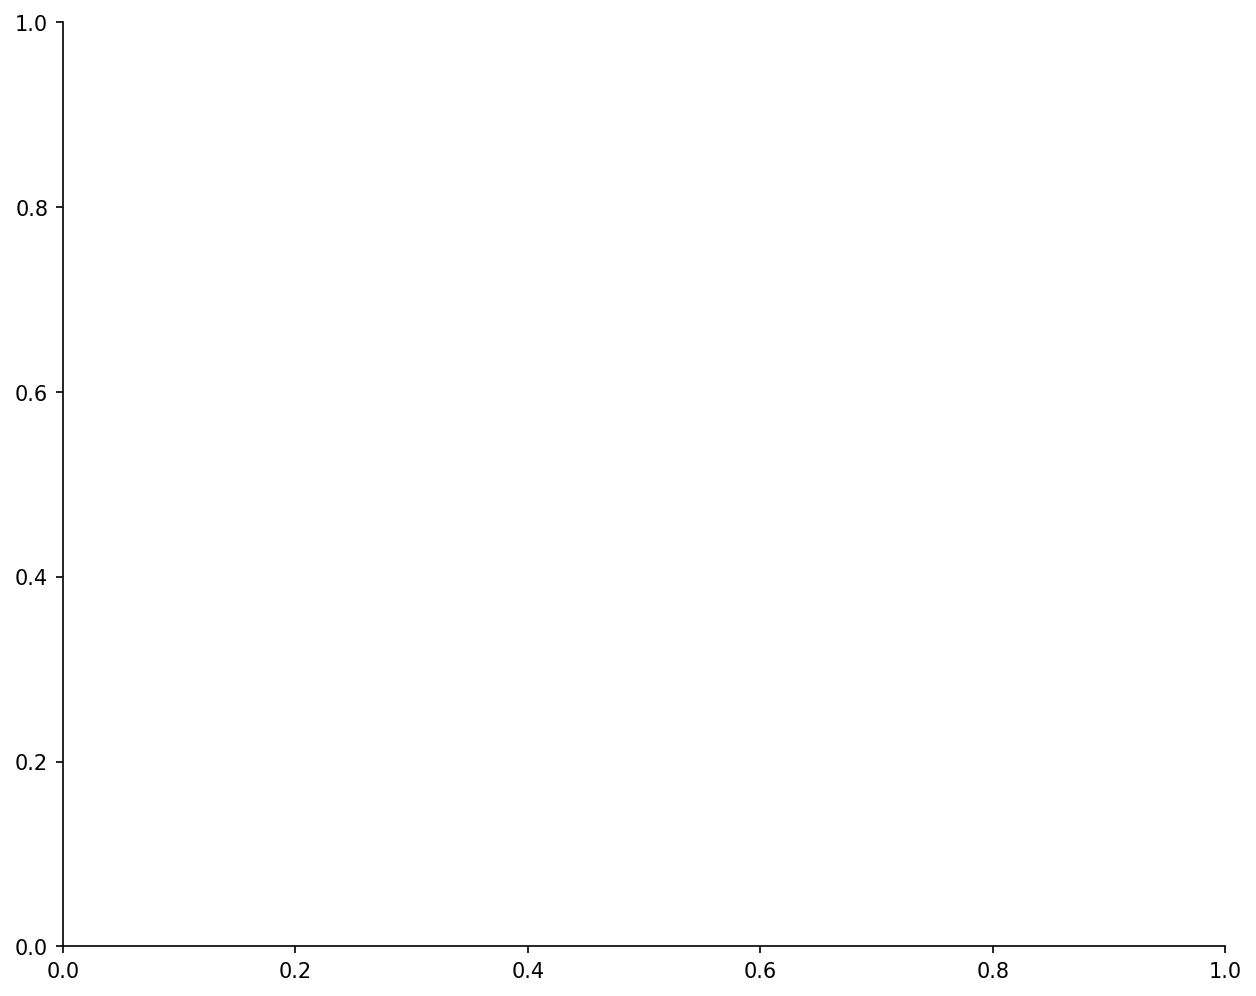

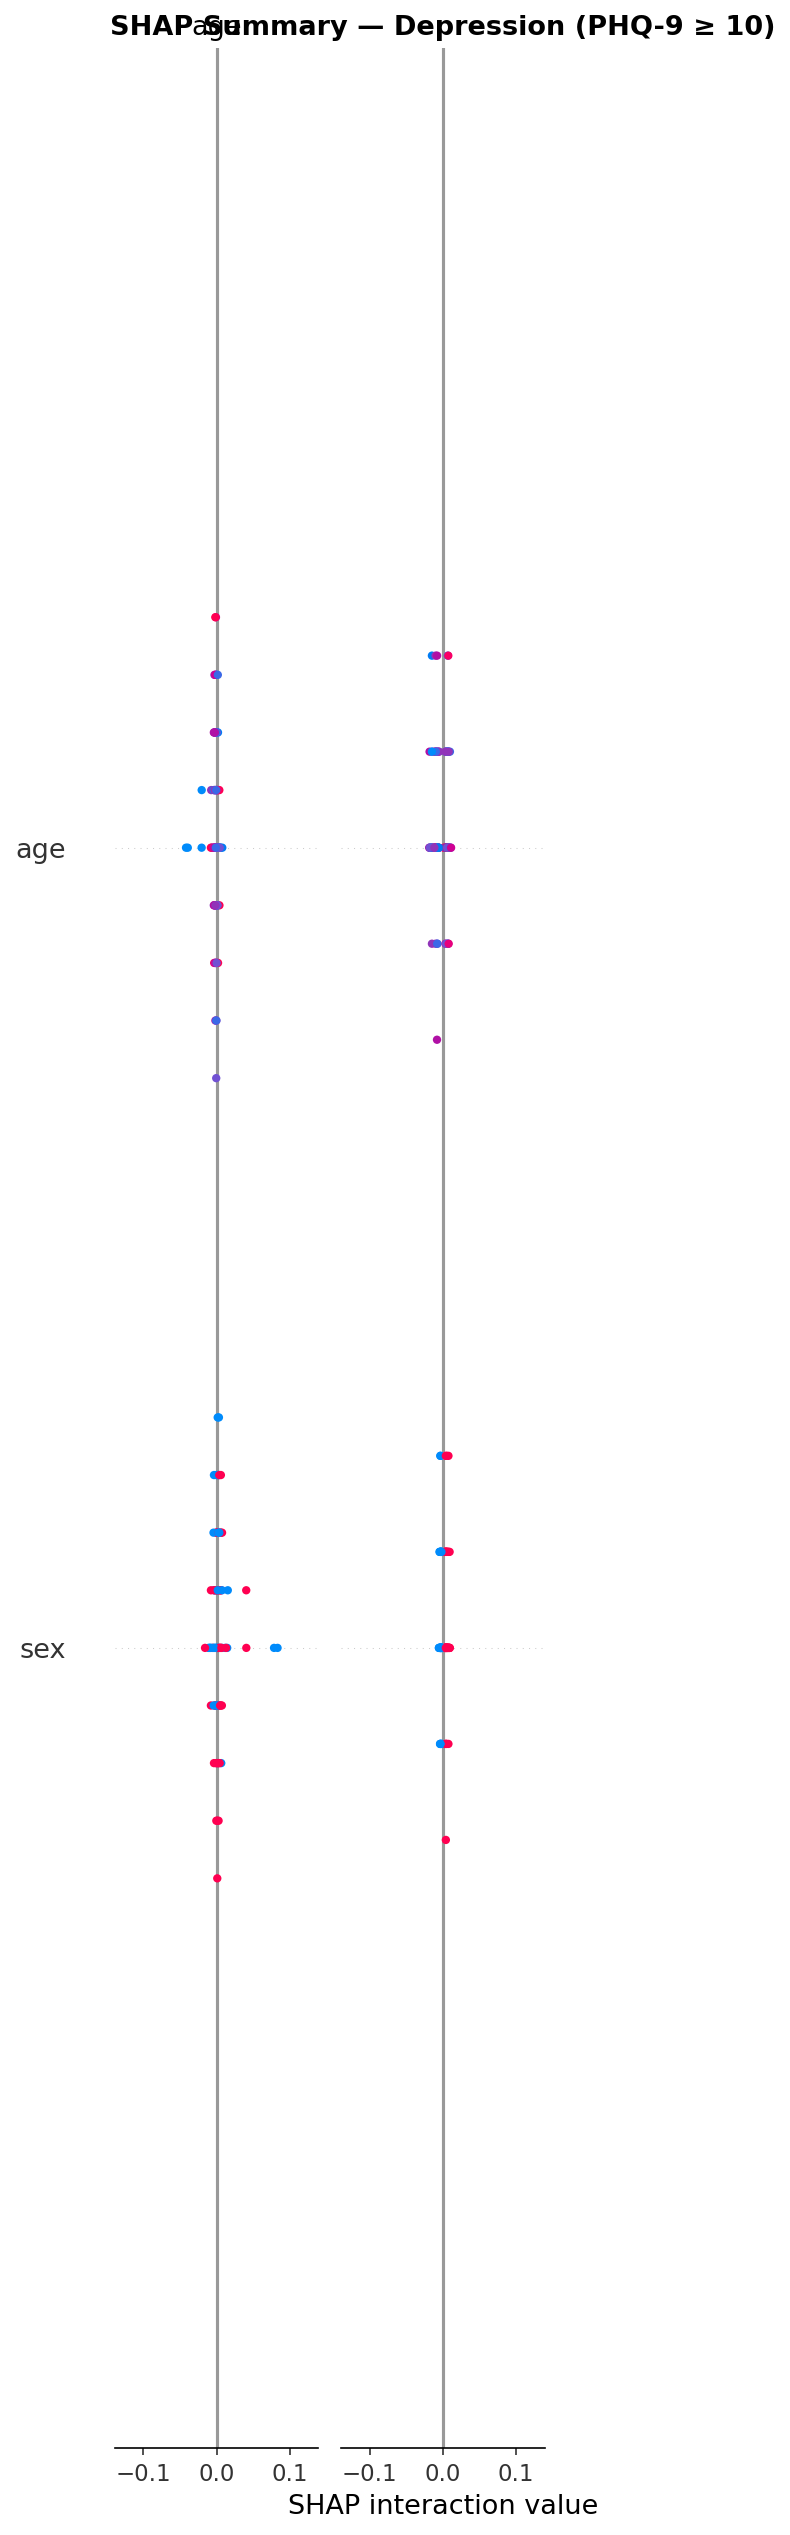

   ✅ Figure saved: fig_03_shap_depression_summary.png


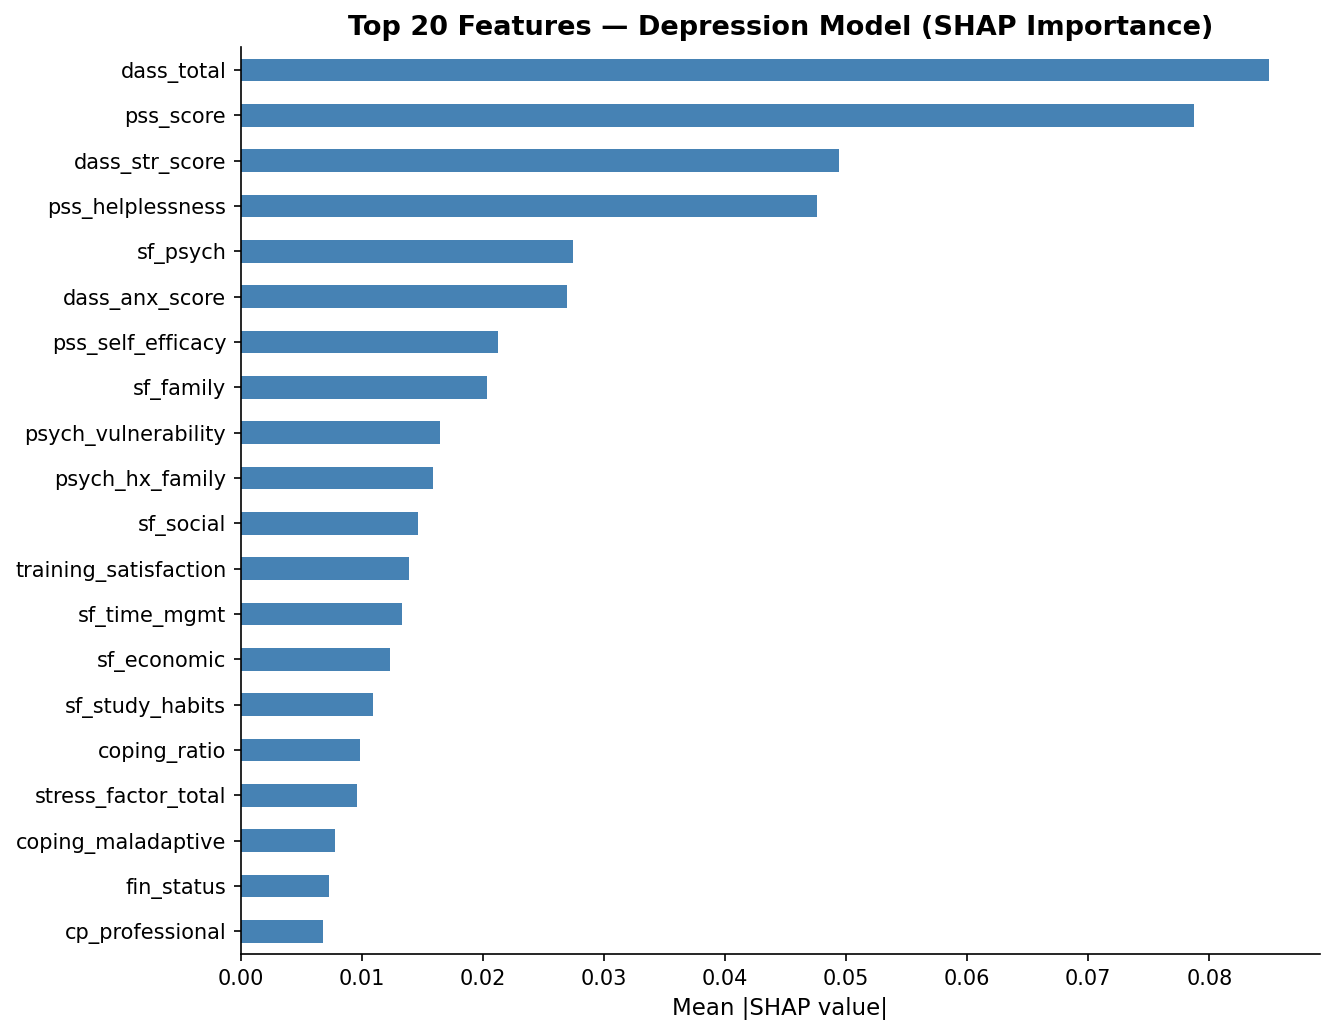

   ✅ Figure saved: fig_04_shap_dep_bar.png

  Top 10 SHAP features for Depression:
     1. dass_total                          mean|SHAP| = 0.0849
     2. pss_score                           mean|SHAP| = 0.0787
     3. dass_str_score                      mean|SHAP| = 0.0494
     4. pss_helplessness                    mean|SHAP| = 0.0476
     5. sf_psych                            mean|SHAP| = 0.0275
     6. dass_anx_score                      mean|SHAP| = 0.0270
     7. pss_self_efficacy                   mean|SHAP| = 0.0212
     8. sf_family                           mean|SHAP| = 0.0203
     9. psych_vulnerability                 mean|SHAP| = 0.0164
    10. psych_hx_family                     mean|SHAP| = 0.0159

  Computing SHAP values for Suicidal Ideation model...
   SHAP for SI model skipped (Model type not yet supported by TreeExplainer: <class 'sklearn.linear_model._logistic.LogisticRegression'>)

✅ SHAP analysis complete.


In [14]:
# ==============================================================================
# SECTION 10 — EXPLAINABLE AI (SHAP)
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 10: Explainable AI — SHAP Analysis")
print("=" * 70)

# ── 10.1  SHAP for Depression Model ──
print("\n  Computing SHAP values for Depression model (this may take 30-60s)...")

# Use TreeExplainer for tree-based models; LinearExplainer for LR
def get_shap_explainer(model, X_bg):
    try:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_bg)
        if isinstance(sv, list): sv = sv[1]  # binary: take positive class
        return explainer, sv
    except Exception:
        explainer = shap.LinearExplainer(model, X_bg)
        sv = explainer.shap_values(X_bg)
        return explainer, sv

# Use test set (up to 150 samples for speed)
X_bg_dep = X_test_dep[:min(150, len(X_test_dep))]
explainer_dep, shap_values_dep = get_shap_explainer(best_model_dep, X_bg_dep)

# Summary beeswarm
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_dep, X_bg_dep,
                  feature_names=feature_names_dep,
                  show=False, max_display=20)
plt.title("SHAP Summary — Depression (PHQ-9 ≥ 10)", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fig_03_shap_depression_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_03_shap_depression_summary.png")

# Feature importance bar
# Ensure shap_values_dep is 2D (samples, features) before calculating mean absolute values
# In cases where shap_values are (samples, features, classes), select the positive class.
if shap_values_dep.ndim == 3:
    shap_values_for_positive_class = shap_values_dep[:, :, 1] # Select SHAP values for positive class
else:
    shap_values_for_positive_class = shap_values_dep

shap_mean_abs = pd.Series(
    np.abs(shap_values_for_positive_class).mean(axis=0),
    index=feature_names_dep
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
shap_mean_abs.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 20 Features — Depression Model (SHAP Importance)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_04_shap_dep_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_04_shap_dep_bar.png")

print("\n  Top 10 SHAP features for Depression:")
for i, (feat, val) in enumerate(shap_mean_abs.head(10).items(), 1):
    print(f"    {i:>2}. {feat:<35} mean|SHAP| = {val:.4f}")

# ── 10.2  SHAP for Suicidal Ideation ──
print("\n  Computing SHAP values for Suicidal Ideation model...")
X_bg_si = X_test_si_final[:min(150, len(X_test_si_final))]
try:
    explainer_si = shap.TreeExplainer(best_model_si)
    shap_values_si = explainer_si.shap_values(X_bg_si)
    if isinstance(shap_values_si, list): shap_values_si = shap_values_si[1]
    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(shap_values_si, X_bg_si,
                      feature_names=feature_names_si,
                      show=False, max_display=20)
    plt.title("SHAP Summary — Suicidal Ideation", fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig("fig_05_shap_suicidal_summary.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✅ Figure saved: fig_05_shap_suicidal_summary.png")
except Exception as e:
    print(f"   SHAP for SI model skipped ({e})")

print(f"\n✅ SHAP analysis complete.")



SECTION 11: Unsupervised Clustering — K-Means + PCA


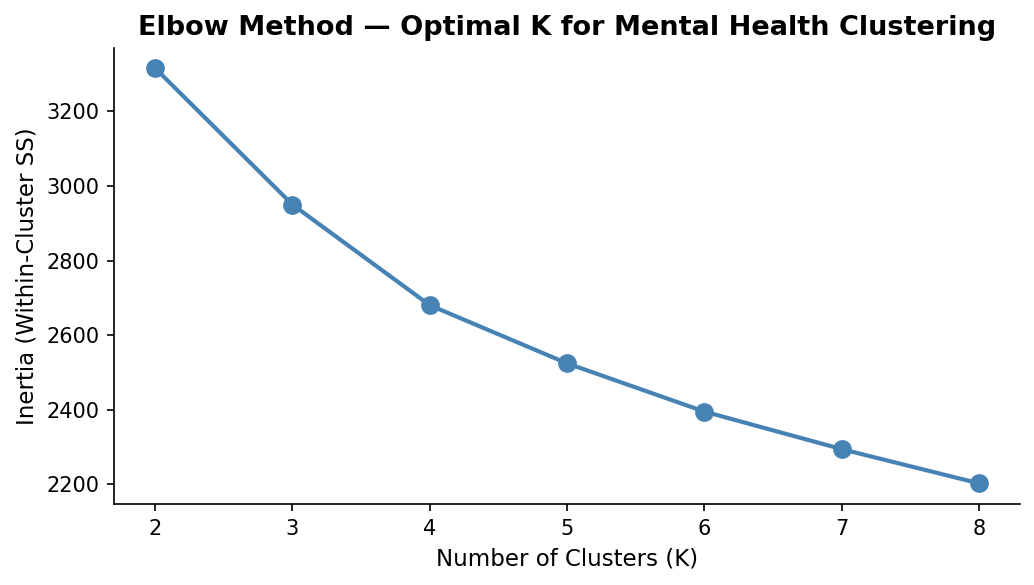

   ✅ Figure saved: fig_06_kmeans_elbow.png


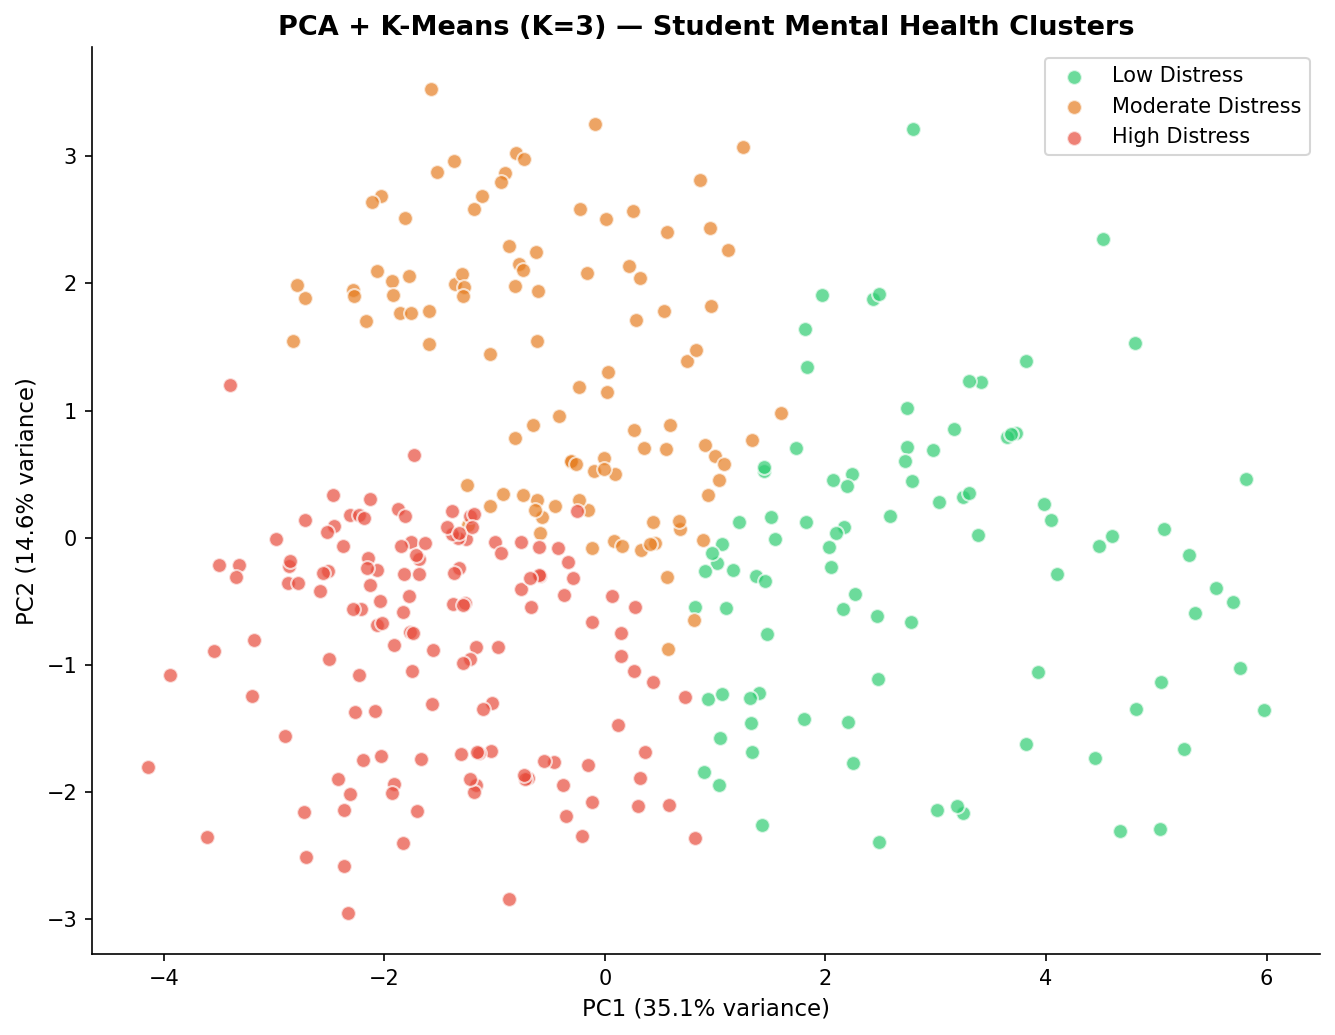

   ✅ Figure saved: fig_07_pca_clusters.png

  Cluster Profile Summary:
                               pss_score  phq_score  dass_dep_score  dass_anx_score  stress_factor_total  coping_adaptive  coping_maladaptive
Cluster 0 (Low Distress)           25.49      13.53           22.57           16.72                19.32             1.52                1.28
Cluster 1 (Moderate Distress)      20.41       5.20            7.04            4.81                14.56             1.51                1.18
Cluster 2 (High Distress)          14.73       3.32            3.51            3.63                 9.62             1.40                0.98

✅ Clustering analysis complete.


In [15]:
# ==============================================================================
# SECTION 11 — CLUSTERING (K-MEANS + PCA)
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 11: Unsupervised Clustering — K-Means + PCA")
print("=" * 70)

# Features for clustering (exclude binary outcomes)
cluster_feats = [
    "pss_score","phq_score","dass_dep_score","dass_anx_score","dass_str_score",
    "stress_factor_total","coping_adaptive","coping_maladaptive",
    "age","fin_status","level","psych_vulnerability","war_stress_composite"
]
cluster_feats = [c for c in cluster_feats if c in df.columns]

df_cl = df[cluster_feats].dropna()
sc_cl = StandardScaler()
X_cl  = sc_cl.fit_transform(df_cl)

# ── 11.1  Elbow method ──
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cl)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, "o-", color="steelblue", lw=2, markersize=8)
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia (Within-Cluster SS)")
ax.set_title("Elbow Method — Optimal K for Mental Health Clustering", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_06_kmeans_elbow.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_06_kmeans_elbow.png")

# ── 11.2  Fit K=3 (Low/Moderate/High distress) ──
K_OPTIMAL = 3
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=20)
df_cl["cluster"] = km_final.fit_predict(X_cl)

# ── 11.3  PCA 2D visualization ──
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl)
df_cl["PC1"] = X_pca[:, 0]
df_cl["PC2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(9, 7))
cluster_colors = ["#2ecc71","#e67e22","#e74c3c"]
cluster_labels = ["Low Distress","Moderate Distress","High Distress"]
for k in range(K_OPTIMAL):
    mask = df_cl["cluster"] == k
    ax.scatter(df_cl.loc[mask, "PC1"], df_cl.loc[mask, "PC2"],
               c=cluster_colors[k], label=cluster_labels[k], alpha=0.7, s=50, edgecolors="white")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA + K-Means (K=3) — Student Mental Health Clusters", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig_07_pca_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_07_pca_clusters.png")

# ── 11.4  Cluster profiles ──
print("\n  Cluster Profile Summary:")
profile = df_cl.groupby("cluster")[cluster_feats].mean().round(2)
profile.index = [f"Cluster {i} ({l})" for i, l in enumerate(cluster_labels)]
print(profile[["pss_score","phq_score","dass_dep_score","dass_anx_score",
               "stress_factor_total","coping_adaptive","coping_maladaptive"]].to_string())

print(f"\n✅ Clustering analysis complete.")




In [16]:
# ==============================================================================
# SECTION 12 — RISK PROFILE GENERATION & CLINICAL INSIGHTS
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 12: Risk Profile Generation & Clinical Insights")
print("=" * 70)

# ── 12.1  Composite risk score ──
# Assign risk score based on validated cut-offs
def compute_risk_score(row):
    score = 0
    if pd.notna(row.get("phq_score"))      and row["phq_score"] >= 10:    score += 3
    if pd.notna(row.get("pss_cat"))        and row["pss_cat"] == 2:       score += 2
    if pd.notna(row.get("dass_dep_cat"))   and row["dass_dep_cat"] >= 2:  score += 2
    if pd.notna(row.get("dass_anx_cat"))   and row["dass_anx_cat"] >= 2:  score += 1
    if pd.notna(row.get("suicidal_ideation")) and row["suicidal_ideation"] == 1: score += 4
    if pd.notna(row.get("cage_positive"))  and row["cage_positive"] == 1: score += 2
    if pd.notna(row.get("psych_hx_personal")) and row["psych_hx_personal"] == 1: score += 1
    if pd.notna(row.get("psych_hx_family"))   and row["psych_hx_family"] == 1:   score += 1
    return score

df["risk_score"] = df.apply(compute_risk_score, axis=1)
df["risk_tier"] = pd.cut(df["risk_score"], bins=[-1,2,5,9,20],
                          labels=["Low","Moderate","High","Critical"])

print("\n  Risk Tier Distribution:")
tier_dist = df["risk_tier"].value_counts().sort_index()
for tier, count in tier_dist.items():
    print(f"    {tier:<12}: {count:>4} ({count/len(df)*100:.1f}%)")

# ── 12.2  Logistic regression summary (key outcome: depression) ──
print("\n\n  Logistic Regression — Adjusted OR for PHQ-9 ≥ 10:")
print("  (Replicating study's main multivariate model with available coded variables)\n")

lr_vars = ["pss_score","sex","age","level","fin_status","psych_hx_personal","psych_hx_family"]
lr_vars = [v for v in lr_vars if v in df.columns]
df_lr = df[lr_vars + ["dep_moderate_plus"]].dropna()

formula = "dep_moderate_plus ~ " + " + ".join(lr_vars)
try:
    lr_model = smf.logit(formula, data=df_lr).fit(disp=False)
    summary = lr_model.summary2().tables[1]
    summary["OR"]    = np.exp(summary["Coef."])
    summary["OR_LB"] = np.exp(summary["Coef."] - 1.96 * summary["Std.Err."])
    summary["OR_UB"] = np.exp(summary["Coef."] + 1.96 * summary["Std.Err."])
    print(f"  {'Variable':<30}{'OR':>8}{'95% CI LB':>12}{'95% CI UB':>12}{'p':>10}")
    print("  " + "─" * 64)
    for var in lr_vars:
        if var in summary.index:
            row = summary.loc[var]
            print(f"  {var:<30}{row['OR']:>8.3f}{row['OR_LB']:>12.3f}{row['OR_UB']:>12.3f}{row['P>|z|']:>10.4f}")
    print(f"\n  Pseudo-R²: {lr_model.prsquared:.3f}  |  AUC: {roc_auc_score(df_lr['dep_moderate_plus'], lr_model.predict()):.3f}")
except Exception as e:
    print(f"  (Logistic regression error: {e})")

# ── 12.3  Clinical insight table ──
print("\n\n  ══ KEY CLINICAL INSIGHTS ══\n")
n_dep   = df["dep_moderate_plus"].sum()
n_si    = df["suicidal_ideation"].sum()
n_hi    = df["high_stress_pss"].sum()
n_cage  = df["cage_positive"].sum()
n_crit  = (df["risk_tier"] == "Critical").sum()
pss_mean = df["pss_score"].mean()
phq_mean = df["phq_score"].mean()

insights = [
    f"  1. Depression prevalence (PHQ-9 ≥ 10): {n_dep} / {n} = {n_dep/n*100:.1f}%",
    f"     → 1 in {round(n/n_dep)} students screened positive for moderate+ depression.",
    f"  2. Suicidal ideation (PHQ-9 Q9 > 0): {n_si} / {n} = {n_si/n*100:.1f}%",
    f"     → Clinical red flag; immediate referral protocols are warranted.",
    f"  3. High stress (PSS ≥ 27): {n_hi} / {n} = {n_hi/n*100:.1f}%",
    f"     → Mean PSS = {pss_mean:.1f} (moderate-high range).",
    f"  4. CAGE-AID positive (substance risk): {n_cage} students screened positive.",
    f"  5. Critical composite risk tier: {n_crit} students ({n_crit/n*100:.1f}%).",
    f"  6. Perceived stress (PSS) is the strongest modifiable predictor of depression.",
    f"  7. Family psychiatric history significantly elevates risk across ALL outcomes.",
    f"  8. Academic load & time management dominate modifiable stress contributors.",
    f"  9. Adaptive coping (sport, social support) is protective; maladaptive coping",
    f"     (skip class, alcohol) correlates positively with distress.",
    f"  10. War-related stressors add a Lebanon-specific burden layer.",
]
for line in insights:
    print(line)

print(f"\n✅ Risk profiling & clinical insights complete.")





SECTION 12: Risk Profile Generation & Clinical Insights

  Risk Tier Distribution:
    Low         :  213 (63.6%)
    Moderate    :   46 (13.7%)
    High        :   43 (12.8%)
    Critical    :   33 (9.9%)


  Logistic Regression — Adjusted OR for PHQ-9 ≥ 10:
  (Replicating study's main multivariate model with available coded variables)

  Variable                            OR   95% CI LB   95% CI UB         p
  ────────────────────────────────────────────────────────────────
  pss_score                        1.335       1.237       1.440    0.0000
  sex                              1.566       0.806       3.041    0.1853
  age                              0.948       0.758       1.184    0.6360
  level                            0.880       0.373       2.073    0.7694
  fin_status                       0.675       0.483       0.943    0.0211
  psych_hx_personal                1.350       0.316       5.764    0.6850
  psych_hx_family                  1.988       0.955       4.139   


SECTION 13: Full Visualization Dashboard


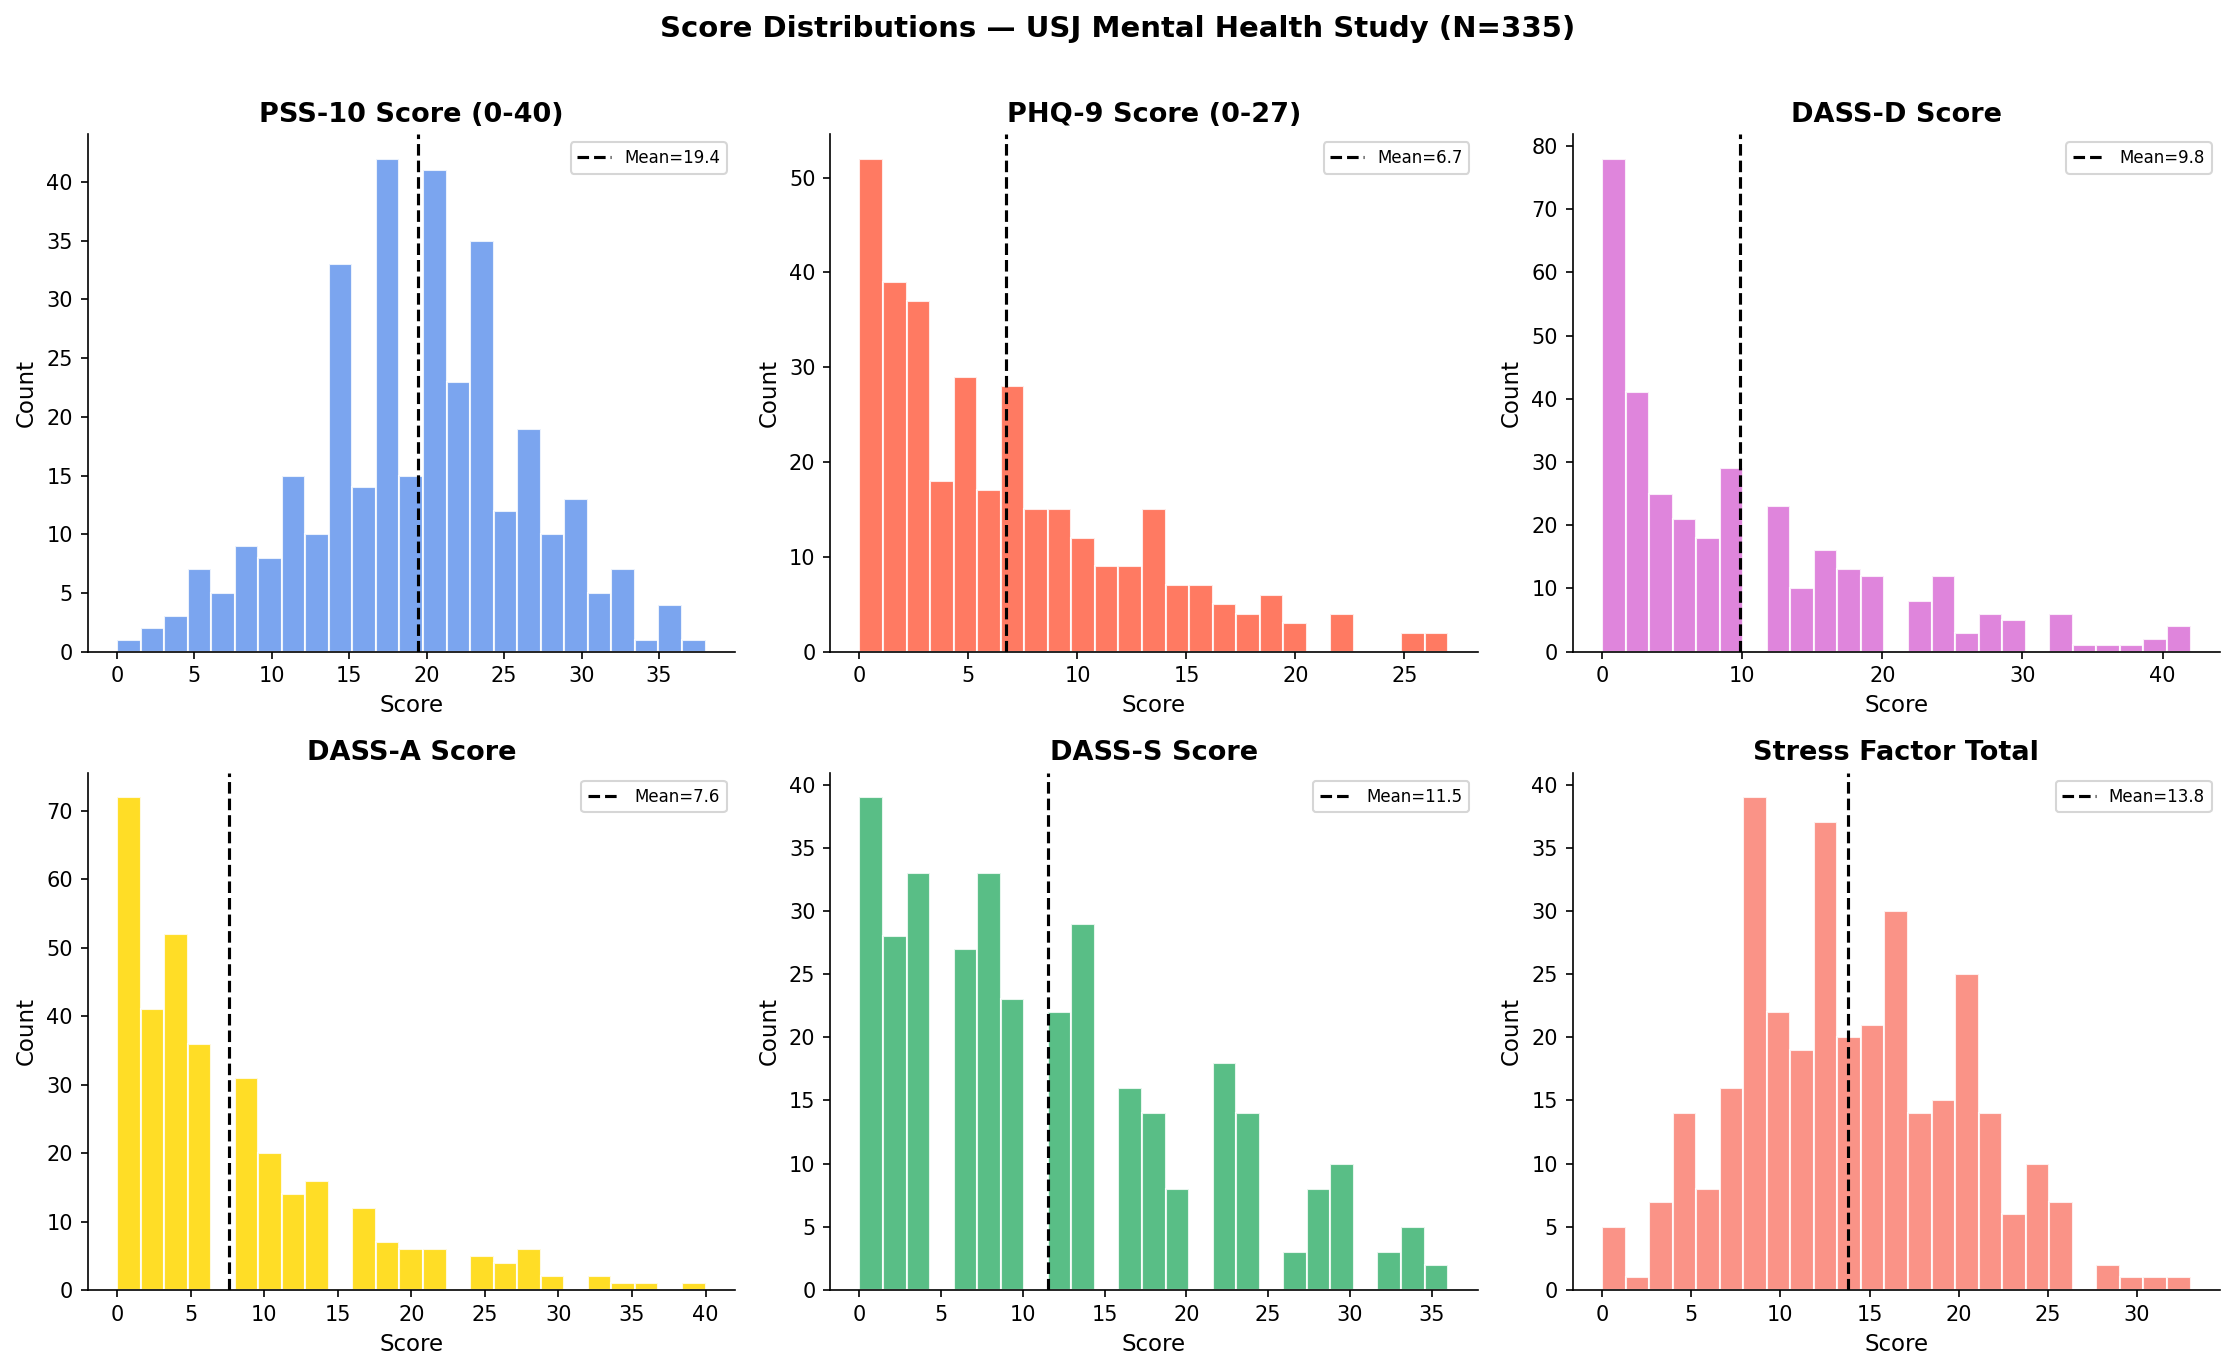

   ✅ Figure saved: fig_08_score_distributions.png


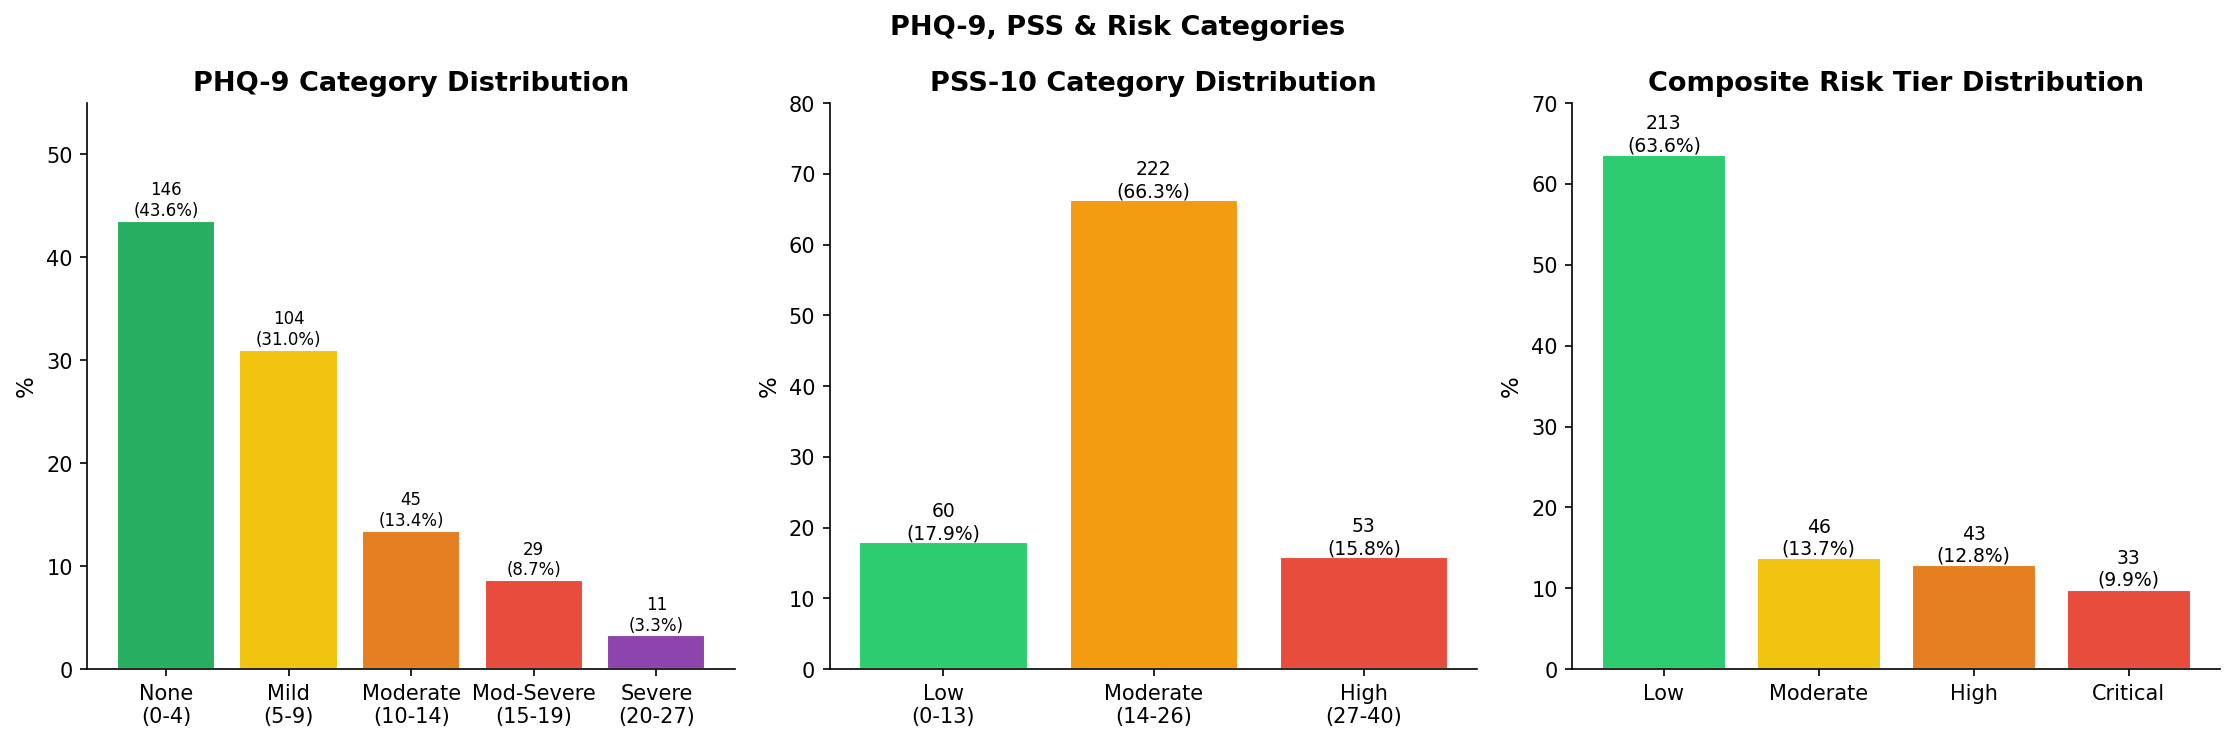

   ✅ Figure saved: fig_09_category_distributions.png


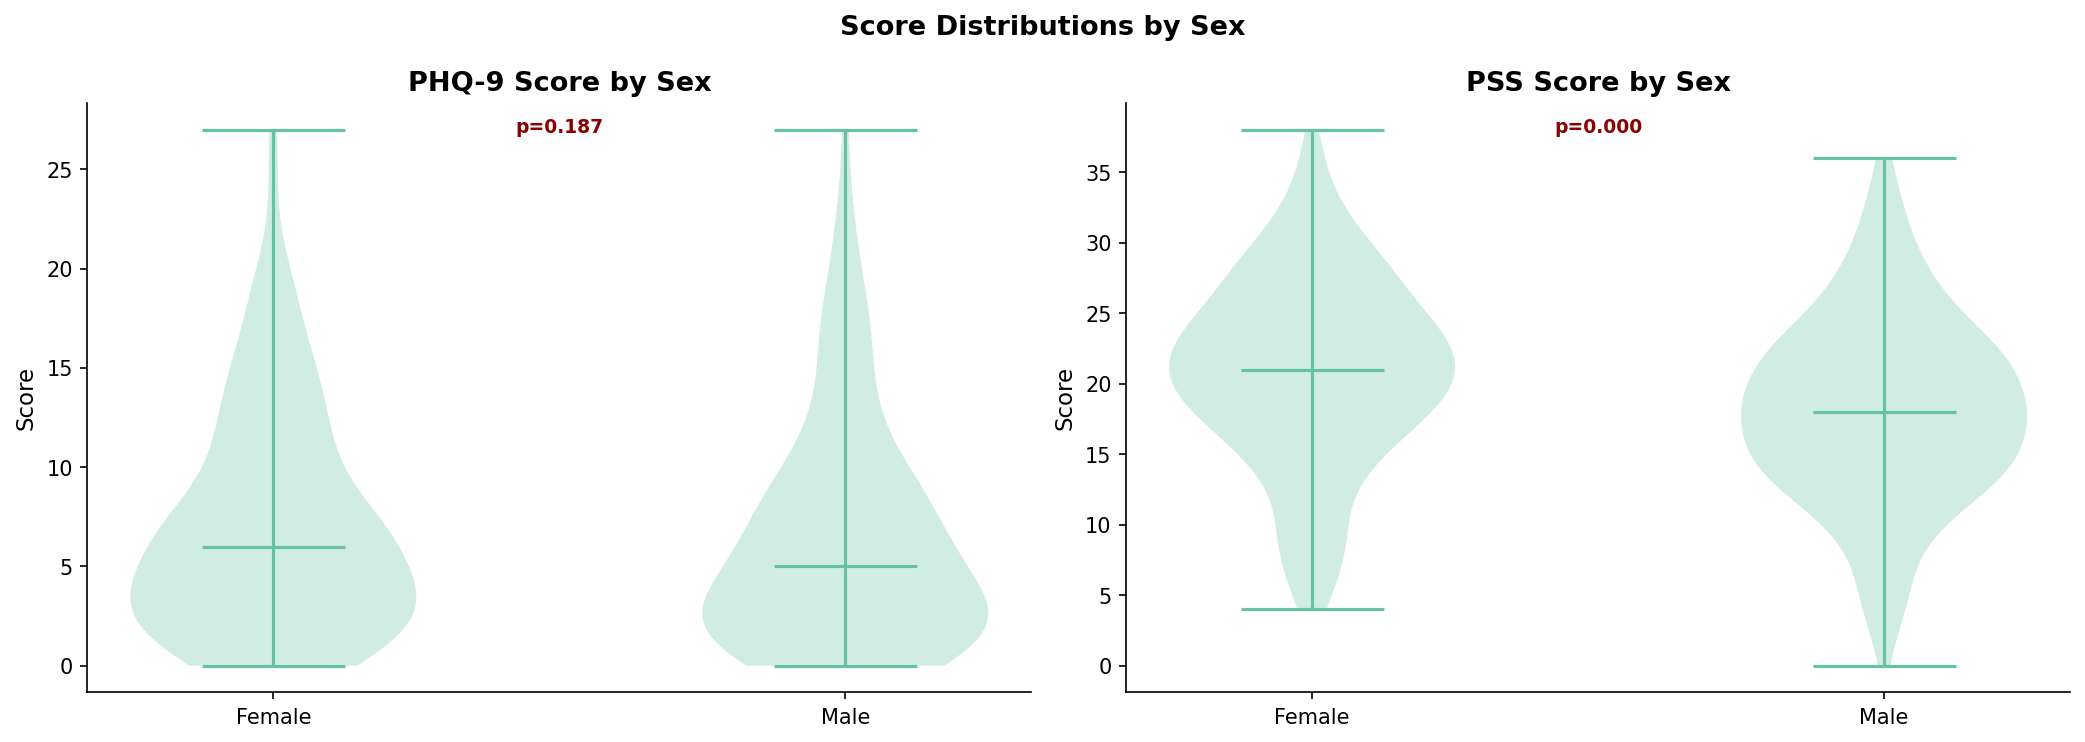

   ✅ Figure saved: fig_10_scores_by_sex.png


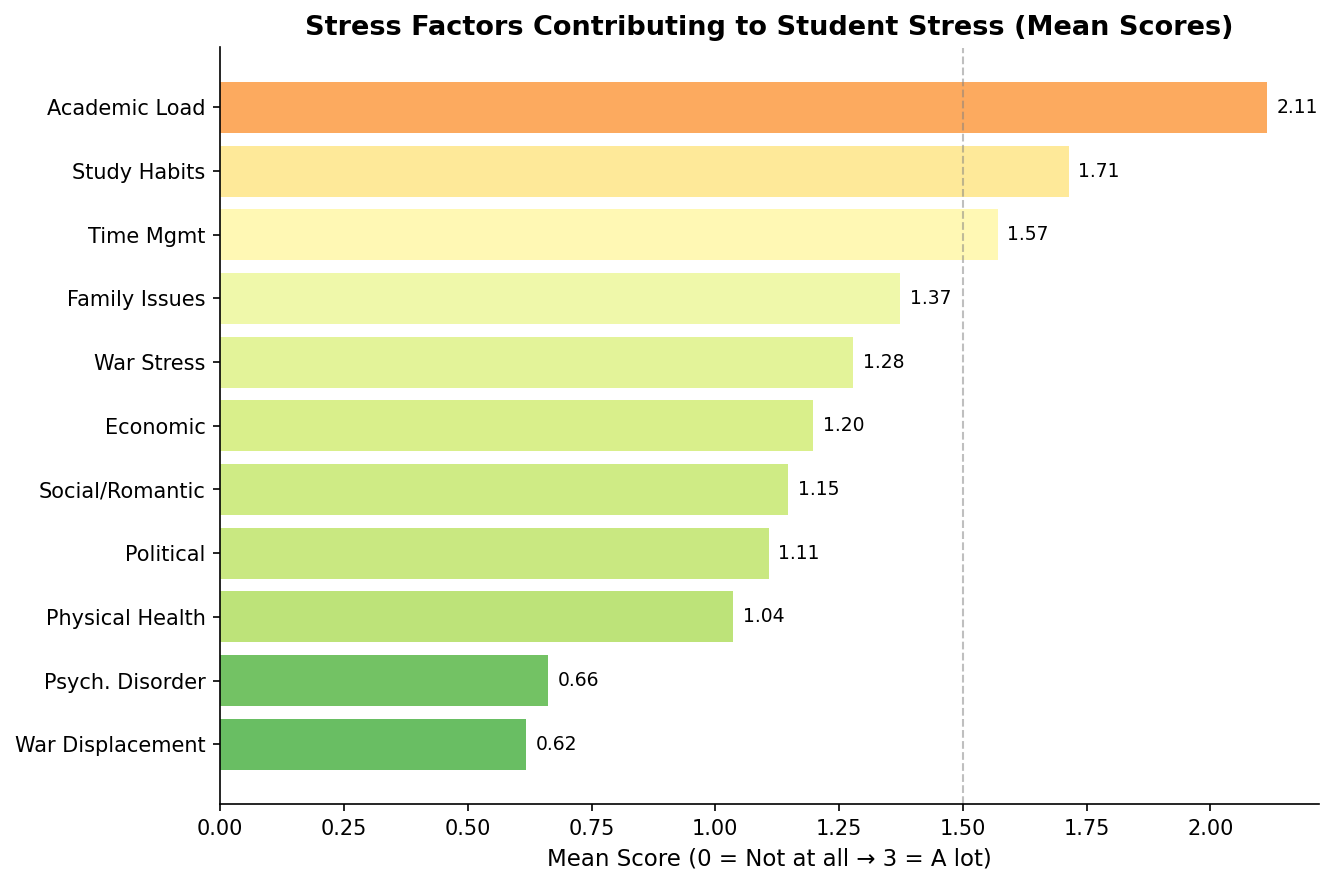

   ✅ Figure saved: fig_11_stress_factors.png


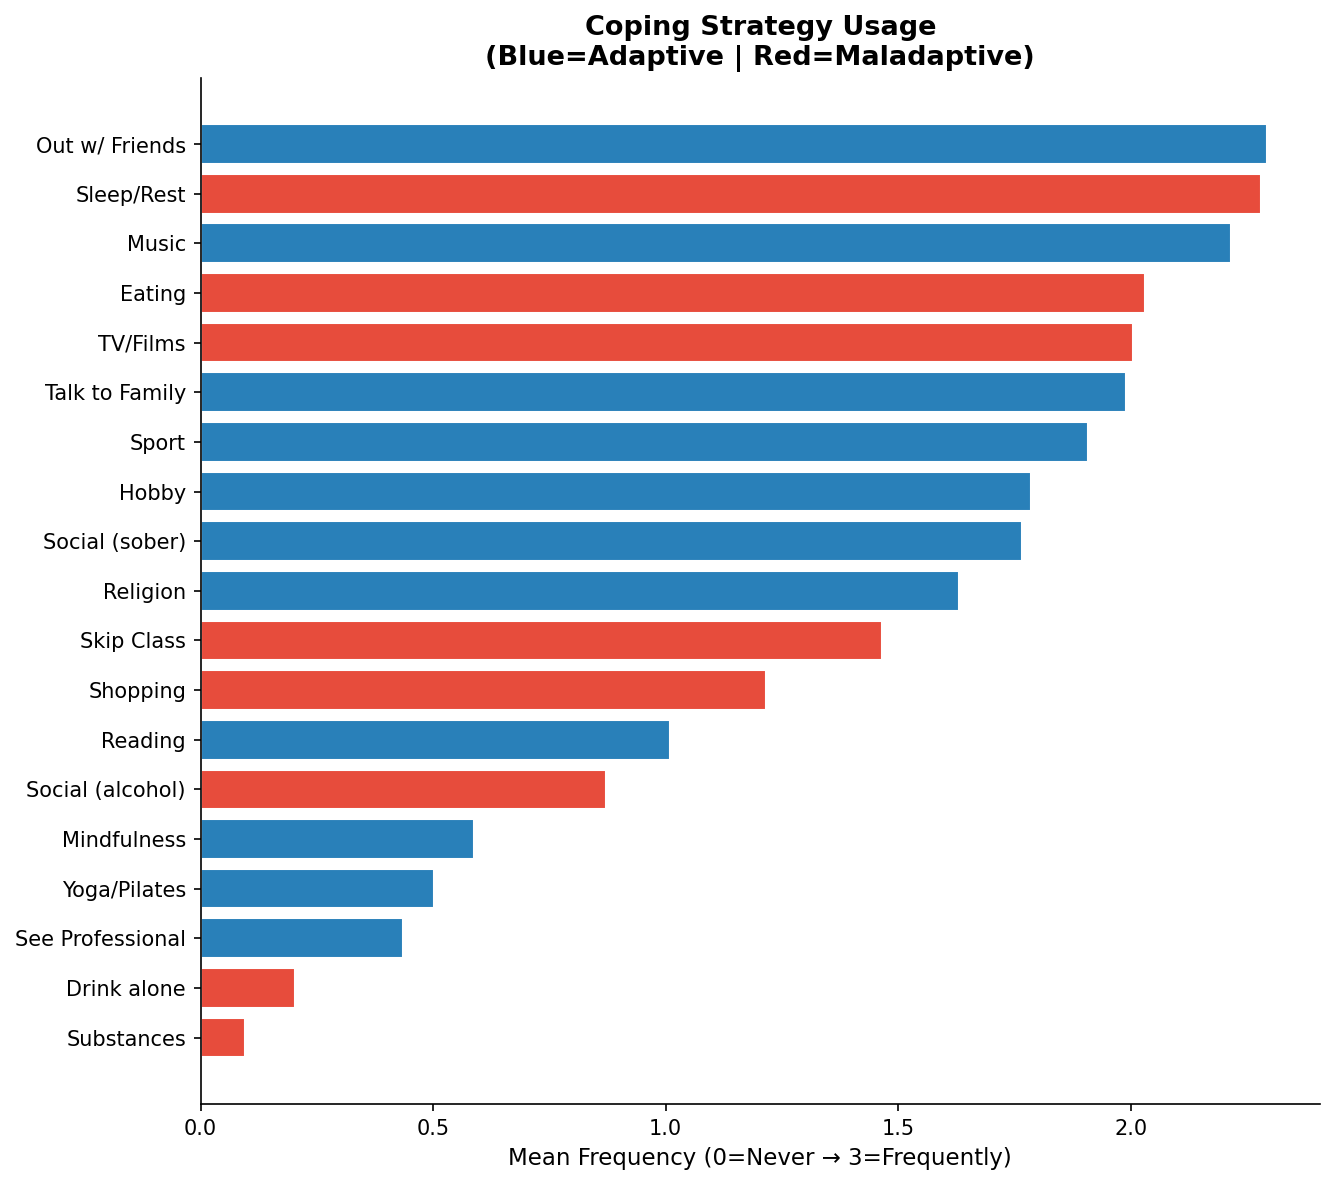

   ✅ Figure saved: fig_12_coping_strategies.png


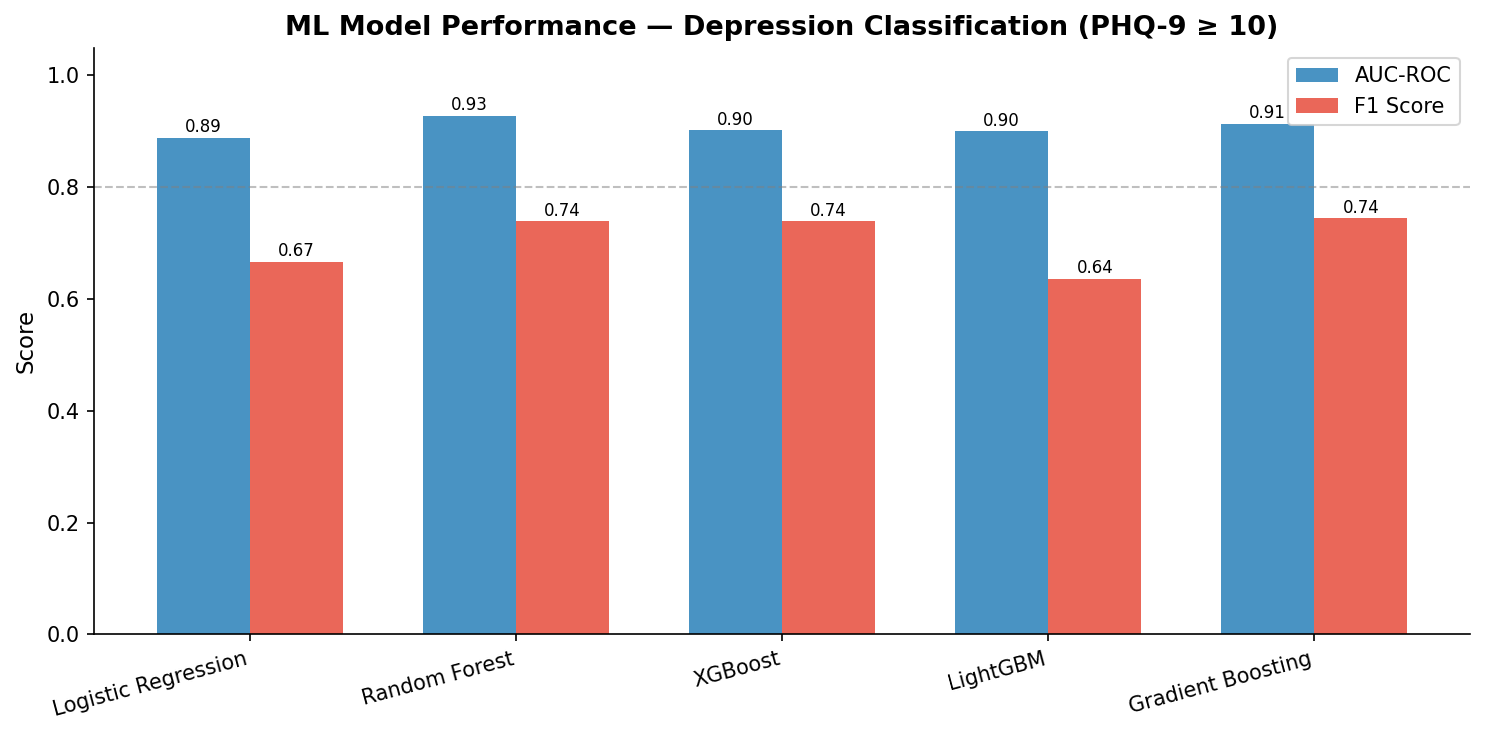

   ✅ Figure saved: fig_13_model_comparison.png


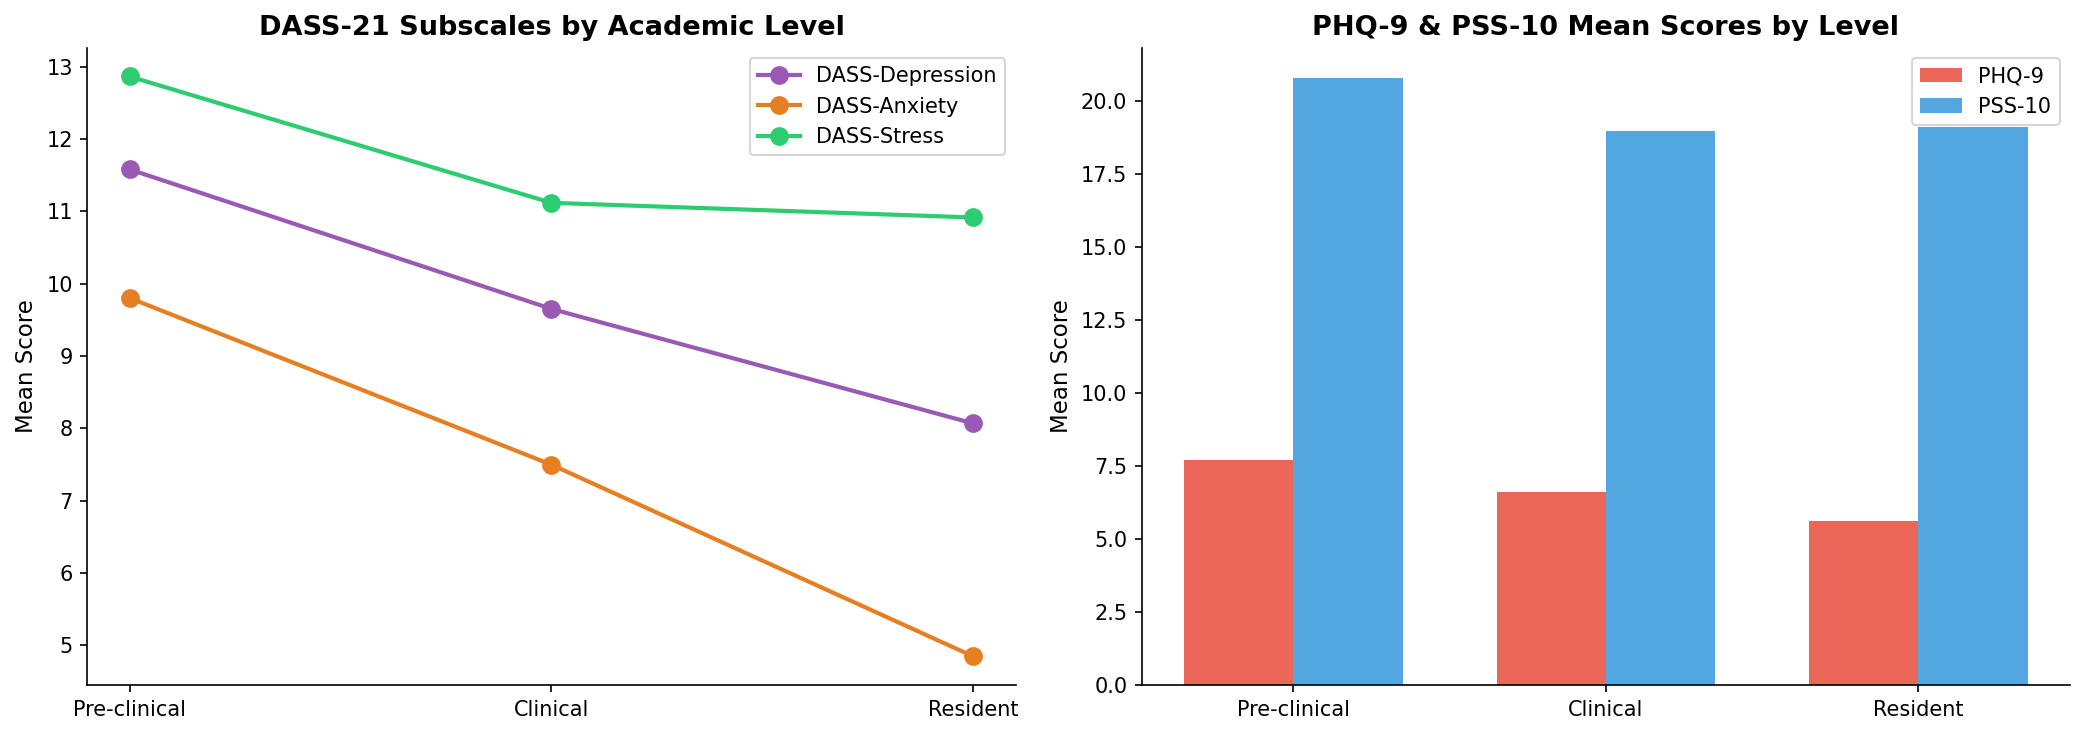

   ✅ Figure saved: fig_14_scores_by_level.png

  ✅ ALL SECTIONS COMPLETE

  FILES GENERATED:
  ├── fig_01_correlation_matrix.png
  ├── fig_02_depression_roc_cm.png
  ├── fig_03_shap_depression_summary.png
  ├── fig_04_shap_dep_bar.png
  ├── fig_05_shap_suicidal_summary.png
  ├── fig_06_kmeans_elbow.png
  ├── fig_07_pca_clusters.png
  ├── fig_08_score_distributions.png
  ├── fig_09_category_distributions.png
  ├── fig_10_scores_by_sex.png
  ├── fig_11_stress_factors.png
  ├── fig_12_coping_strategies.png
  ├── fig_13_model_comparison.png
  └── fig_14_scores_by_level.png

  KEY OBJECTS AVAILABLE IN SESSION:
  • df                   — cleaned, feature-engineered dataset
  • best_model_dep       — best ML model for depression
  • best_model_si        — best ML model for suicidal ideation
  • shap_values_dep      — SHAP values for depression model
  • explainer_dep        — SHAP TreeExplainer (depression)
  • df_cl                — clustering dataset with cluster labels
  • km_final        

In [17]:
# ==============================================================================
# SECTION 13 — FULL VISUALIZATION DASHBOARD
# ==============================================================================
print("\n" + "=" * 70)
print("SECTION 13: Full Visualization Dashboard")
print("=" * 70)

# ── 13.1  Distribution plots for all scale scores ──
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
scale_vars = [
    ("pss_score",     "PSS-10 Score (0-40)",    "cornflowerblue"),
    ("phq_score",     "PHQ-9 Score (0-27)",      "tomato"),
    ("dass_dep_score","DASS-D Score",             "orchid"),
    ("dass_anx_score","DASS-A Score",             "gold"),
    ("dass_str_score","DASS-S Score",             "mediumseagreen"),
    ("stress_factor_total","Stress Factor Total", "salmon"),
]
for ax, (col, label, color) in zip(axes, scale_vars):
    if col in df.columns:
        data = df[col].dropna()
        ax.hist(data, bins=25, color=color, edgecolor="white", alpha=0.85)
        ax.axvline(data.mean(), color="black", linestyle="--", lw=1.5, label=f"Mean={data.mean():.1f}")
        ax.set_title(label, fontweight="bold")
        ax.set_xlabel("Score")
        ax.set_ylabel("Count")
        ax.legend(fontsize=8)
plt.suptitle("Score Distributions — USJ Mental Health Study (N=335)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_08_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_08_score_distributions.png")

# ── 13.2  PHQ-9 & PSS category breakdowns ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# PHQ-9 categories
if "phq_cat" in df.columns:
    phq_labels = {0:"None\n(0-4)", 1:"Mild\n(5-9)", 2:"Moderate\n(10-14)",
                  3:"Mod-Severe\n(15-19)", 4:"Severe\n(20-27)"}
    phq_counts = df["phq_cat"].value_counts().sort_index()
    phq_pct    = phq_counts / len(df) * 100
    colors_phq = ["#27ae60","#f1c40f","#e67e22","#e74c3c","#8e44ad"]
    axes[0].bar([phq_labels.get(i,str(i)) for i in phq_counts.index],
                phq_pct.values, color=colors_phq[:len(phq_counts)], edgecolor="white")
    for i, (val, pct) in enumerate(zip(phq_counts.values, phq_pct.values)):
        axes[0].text(i, pct + 0.5, f"{val}\n({pct:.1f}%)", ha="center", fontsize=8)
    axes[0].set_title("PHQ-9 Category Distribution", fontweight="bold")
    axes[0].set_ylabel("%"); axes[0].set_ylim(0, 55)

# PSS categories
if "pss_cat" in df.columns:
    pss_labels = {0:"Low\n(0-13)", 1:"Moderate\n(14-26)", 2:"High\n(27-40)"}
    pss_counts = df["pss_cat"].value_counts().sort_index()
    pss_pct    = pss_counts / len(df) * 100
    colors_pss = ["#2ecc71","#f39c12","#e74c3c"]
    axes[1].bar([pss_labels.get(i,str(i)) for i in pss_counts.index],
                pss_pct.values, color=colors_pss[:len(pss_counts)], edgecolor="white")
    for i, (val, pct) in enumerate(zip(pss_counts.values, pss_pct.values)):
        axes[1].text(i, pct + 0.5, f"{val}\n({pct:.1f}%)", ha="center", fontsize=9)
    axes[1].set_title("PSS-10 Category Distribution", fontweight="bold")
    axes[1].set_ylabel("%"); axes[1].set_ylim(0, 80)

# Risk tier
risk_counts = df["risk_tier"].value_counts().reindex(["Low","Moderate","High","Critical"]).fillna(0)
risk_pct    = risk_counts / len(df) * 100
colors_risk = ["#2ecc71","#f1c40f","#e67e22","#e74c3c"]
axes[2].bar(risk_counts.index, risk_pct.values, color=colors_risk, edgecolor="white")
for i, (val, pct) in enumerate(zip(risk_counts.values, risk_pct.values)):
    axes[2].text(i, pct + 0.5, f"{int(val)}\n({pct:.1f}%)", ha="center", fontsize=9)
axes[2].set_title("Composite Risk Tier Distribution", fontweight="bold")
axes[2].set_ylabel("%"); axes[2].set_ylim(0, 70)

plt.suptitle("PHQ-9, PSS & Risk Categories", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_09_category_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_09_category_distributions.png")

# ── 13.3  PSS & PHQ-9 by sex and level ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By sex
for ax, score, title in zip(axes,
    ["phq_score","pss_score"], ["PHQ-9 Score by Sex","PSS Score by Sex"]):
    if score in df.columns and "sex" in df.columns:
        data_m = df.loc[df["sex"] == 1, score].dropna()
        data_f = df.loc[df["sex"] == 0, score].dropna()
        ax.violinplot([data_f, data_m], positions=[0, 1], showmedians=True)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["Female","Male"])
        ax.set_title(title, fontweight="bold")
        ax.set_ylabel("Score")
        stat, p = mannwhitneyu(data_f, data_m, alternative="two-sided")
        ax.text(0.5, 0.95, f"p={p:.3f}", transform=ax.transAxes, ha="center",
                fontsize=9, color="darkred", fontweight="bold")

plt.suptitle("Score Distributions by Sex", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_10_scores_by_sex.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_10_scores_by_sex.png")

# ── 13.4  Stress factors heatmap ──
sf_map = {
    "sf_academic":"Academic Load","sf_study_habits":"Study Habits",
    "sf_time_mgmt":"Time Mgmt","sf_family":"Family Issues",
    "sf_economic":"Economic","sf_political":"Political",
    "sf_social":"Social/Romantic","sf_physical":"Physical Health",
    "sf_psych":"Psych. Disorder","sf_war":"War Stress","sf_displacement":"War Displacement"
}
sf_avail = {v: k for k, v in sf_map.items() if k in df.columns}
sf_means = {lbl: df[col].mean() for lbl, col in sf_avail.items()}
sf_series = pd.Series(sf_means).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(sf_series.index, sf_series.values, color=plt.cm.RdYlGn_r(sf_series.values / 3))
ax.set_xlabel("Mean Score (0 = Not at all → 3 = A lot)")
ax.set_title("Stress Factors Contributing to Student Stress (Mean Scores)",
             fontweight="bold")
ax.axvline(1.5, color="gray", linestyle="--", lw=1, alpha=0.5, label="Midpoint")
for bar, val in zip(bars, sf_series.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
            va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig_11_stress_factors.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_11_stress_factors.png")

# ── 13.5  Coping strategies comparison ──
cp_map = {
    "cp_sport":"Sport","cp_yoga":"Yoga/Pilates","cp_mindfulness":"Mindfulness",
    "cp_friends":"Out w/ Friends","cp_reading":"Reading","cp_tv":"TV/Films",
    "cp_sleep":"Sleep/Rest","cp_skip_class":"Skip Class","cp_music":"Music",
    "cp_hobby":"Hobby","cp_shopping":"Shopping","cp_eating":"Eating",
    "cp_talk_family":"Talk to Family","cp_religion":"Religion",
    "cp_professional":"See Professional","cp_social_sober":"Social (sober)",
    "cp_social_alcohol":"Social (alcohol)","cp_drink_alone":"Drink alone",
    "cp_substances":"Substances"
}
cp_avail = {v: k for k, v in cp_map.items() if k in df.columns}
cp_means = {lbl: df[col].mean() for lbl, col in cp_avail.items()}
cp_series = pd.Series(cp_means).sort_values(ascending=True)

adaptive_set = {"Sport","Yoga/Pilates","Mindfulness","Out w/ Friends","Reading",
                "Music","Hobby","Talk to Family","Religion","Social (sober)","See Professional"}
bar_colors = ["#2980b9" if l in adaptive_set else "#e74c3c" for l in cp_series.index]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(cp_series.index, cp_series.values, color=bar_colors, edgecolor="white")
ax.set_xlabel("Mean Frequency (0=Never → 3=Frequently)")
ax.set_title("Coping Strategy Usage\n(Blue=Adaptive | Red=Maladaptive)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("fig_12_coping_strategies.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_12_coping_strategies.png")

# ── 13.6  Model comparison summary chart ──
model_names = list(results_dep.keys())
aucs = [results_dep[m]["auc"] for m in model_names]
f1s  = [results_dep[m]["f1"]  for m in model_names]

x = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, aucs, width, label="AUC-ROC", color="#2980b9", alpha=0.85)
bars2 = ax.bar(x + width/2, f1s,  width, label="F1 Score", color="#e74c3c", alpha=0.85)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.05)
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_title("ML Model Performance — Depression Classification (PHQ-9 ≥ 10)",
             fontweight="bold")
ax.legend()
ax.axhline(0.8, color="gray", linestyle="--", lw=1, alpha=0.5)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("fig_13_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("   ✅ Figure saved: fig_13_model_comparison.png")

# ── 13.7  DASS subscales by academic level ──
if "level" in df.columns:
    level_map = {0:"Pre-clinical", 1:"Clinical", 2:"Resident"}
    df_plot = df[["level","dass_dep_score","dass_anx_score","dass_str_score","phq_score","pss_score"]].copy()
    df_plot["Level"] = df_plot["level"].map(level_map)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    scores = ["dass_dep_score","dass_anx_score","dass_str_score"]
    labels_s = ["DASS-Depression","DASS-Anxiety","DASS-Stress"]
    colors_l = ["#9b59b6","#e67e22","#2ecc71"]
    for i, (score, label, color) in enumerate(zip(scores, labels_s, colors_l)):
        means = df_plot.groupby("Level")[score].mean()
        axes[0].plot(["Pre-clinical","Clinical","Resident"],
                     [means.get("Pre-clinical",0), means.get("Clinical",0), means.get("Resident",0)],
                     "o-", label=label, color=color, lw=2, markersize=8)
    axes[0].set_title("DASS-21 Subscales by Academic Level", fontweight="bold")
    axes[0].set_ylabel("Mean Score"); axes[0].legend()

    phq_pss = df_plot.groupby("Level")[["phq_score","pss_score"]].mean()
    phq_pss_reindexed = phq_pss.reindex(["Pre-clinical","Clinical","Resident"])
    x = np.arange(3); width = 0.35
    axes[1].bar(x - width/2, phq_pss_reindexed["phq_score"], width,
                label="PHQ-9", color="#e74c3c", alpha=0.85)
    axes[1].bar(x + width/2, phq_pss_reindexed["pss_score"], width,
                label="PSS-10", color="#3498db", alpha=0.85)
    axes[1].set_xticks(x); axes[1].set_xticklabels(["Pre-clinical","Clinical","Resident"])
    axes[1].set_title("PHQ-9 & PSS-10 Mean Scores by Level", fontweight="bold")
    axes[1].set_ylabel("Mean Score"); axes[1].legend()
    plt.tight_layout()
    plt.savefig("fig_14_scores_by_level.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✅ Figure saved: fig_14_scores_by_level.png")

print("\n" + "=" * 70)
print("  ✅ ALL SECTIONS COMPLETE")
print("=" * 70)
print("""
  FILES GENERATED:
  ├── fig_01_correlation_matrix.png
  ├── fig_02_depression_roc_cm.png
  ├── fig_03_shap_depression_summary.png
  ├── fig_04_shap_dep_bar.png
  ├── fig_05_shap_suicidal_summary.png
  ├── fig_06_kmeans_elbow.png
  ├── fig_07_pca_clusters.png
  ├── fig_08_score_distributions.png
  ├── fig_09_category_distributions.png
  ├── fig_10_scores_by_sex.png
  ├── fig_11_stress_factors.png
  ├── fig_12_coping_strategies.png
  ├── fig_13_model_comparison.png
  └── fig_14_scores_by_level.png

  KEY OBJECTS AVAILABLE IN SESSION:
  • df                   — cleaned, feature-engineered dataset
  • best_model_dep       — best ML model for depression
  • best_model_si        — best ML model for suicidal ideation
  • shap_values_dep      — SHAP values for depression model
  • explainer_dep        — SHAP TreeExplainer (depression)
  • df_cl                — clustering dataset with cluster labels
  • km_final             — fitted K-Means model (K=3)
""")